# Agentic Travel Assistant

An intelligent travel assistant designed to help users search for travel services, retrieve destination information, answer common travel questions, and build personalized travel plans.

The system is implemented as an agentic workflow using **LangGraph** and integrates multiple external services and retrieval components to handle different types of travel-related requests.

The assistant supports capabilities such as:

* Flight search
* Hotel search
* Restaurant recommendations
* Destination information retrieval
* Weather information
* Currency-related assistance
* Travel FAQ retrieval
* Personalized trip planning

The project combines several technologies and external services:

* **LangGraph** for agent workflow orchestration
* **LanceDB** for vector storage and semantic retrieval
* **Amadeus API** for flight and hotel search
* **Tavily Search** for retrieving up-to-date information from the web
* **BAAI/bge-small-en-v1.5** for semantic embeddings
* **LlamaParse** for processing travel-guide documents
* An OpenAI-compatible language model for reasoning, tool selection, and response generation

The assistant communicates in **English** throughout the interaction and dynamically selects the appropriate tools based on the user's request.

---

## Project Pipeline

The implementation is organized into the following stages:

1. Environment configuration
2. Dataset preparation
3. Travel document processing
4. Vector database construction
5. Travel tool implementation
6. LangGraph agent construction
7. Agent testing across different travel scenarios


## Environment Configuration

The project relies on several external APIs and Python libraries to provide retrieval, travel search, and agentic reasoning capabilities.

The main external services include:

* **Language Model API** for natural-language understanding, reasoning, and response generation
* **Tavily API** for web search and up-to-date destination information
* **Amadeus API** for flight and hotel search
* **LlamaParse API** for extracting structured information from the travel-guide document

API credentials are loaded from environment variables and are not stored directly in the notebook.


## Dependencies and Imports

The project dependencies are managed through `requirements.txt`.

This section imports the libraries required for environment configuration, data processing, vector retrieval, external travel APIs, document parsing, language-model interaction, and LangGraph-based agent orchestration.

In [ ]:
import os
import re
import json

from dataclasses import dataclass
from datetime import datetime, timedelta, date
from typing import Any, Dict, List, Optional, Callable, Set, Tuple
from urllib.parse import urlparse

import numpy as np
import pandas as pd
import pyarrow as pa
import PyPDF2
import dateparser
import kagglehub
import lancedb
import langchain_core
import langchain_community
import langchain_text_splitters
import langchain_openai
import langchain_google_genai
import llama_parse
import sentence_transformers
import tavily
import amadeus

from amadeus import Client, ResponseError
from dotenv import load_dotenv
from fuzzywuzzy import fuzz
from llama_parse import LlamaParse
from tavily import TavilyClient

from langchain_core.messages import SystemMessage, HumanMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_openai import ChatOpenAI

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import MessagesState
from langgraph.prebuilt import ToolNode, tools_condition

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'validate_default' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'validate_default' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/tmp/ipython-input-842457441.py:27: DeprecationWarning: The 'llama-parse' package is deprecated and will no longer receive updates. Please migrate to the new unified SDK. See https://developers.llamaindex.ai/python/cloud/llamaparse/getting_started/ and https://github.com/run-llama/llama-cloud-py/blob/main/README.md for migration instructions.
  import llama_parse


## API Configuration

The travel assistant integrates several external services for language-model inference, web search, travel data retrieval, and document parsing.

The required services include:

- **Language Model API** for reasoning, tool selection, and response generation
- **Tavily API** for real-time web search
- **Amadeus API** for flight and hotel search
- **LlamaParse API** for processing the travel-guide document

API credentials are loaded from environment variables using a local `.env` file and are never stored directly in the notebook.

In [ ]:
load_dotenv()

os.environ["OPENAI_BASE_URL"] = os.getenv(
    "OPENAI_BASE_URL",
    "https://api.avalai.ir/v1"
)

## Dataset Preparation

The travel assistant uses multiple structured and unstructured data sources to support airport lookup, currency identification, travel FAQ retrieval, and destination information search.

The main data sources include:

* **IATA Airport Dataset** — airport and city information used to map city names to IATA airport codes
* **Currency Reference Dataset** — country-to-currency mappings stored locally in `data/list-one.csv`
* **Travel FAQ Dataset** — frequently asked travel questions and answers stored in `data/FAQ.js`
* **World Travel Book** — a travel guide used as an unstructured knowledge source for destination-related retrieval

---

### IATA Airport Dataset

The airport dataset is obtained from the Kaggle dataset:

```text
zinovadr/iata-airport-code
```

It contains airport information and IATA codes for airports around the world.

The dataset is processed to construct a city-to-airport mapping that enables the travel assistant to convert user-provided city names into the corresponding IATA airport codes required by travel APIs.

Examples:

```text
Dubai → DXB
Tehran → THR
```

The preprocessing stage also reports the number of valid airports with IATA codes and the number of entries included in the resulting lookup dictionary.

---

### Currency Reference Dataset

Currency information is loaded from the local file:

```text
data/list-one.csv
```

The dataset provides mappings between countries or territories and their corresponding currencies and alphabetic currency codes.

The main fields include:

* `ENTITY` — country or territory name
* `Currency` — currency name
* `Alphabetic-Code` — ISO-style currency code

Example mappings include:

```text
Australia → Australian Dollar → AUD
Brazil → Brazilian Real → BRL
Iran → Iranian Rial → IRR
```

This dataset is used by the travel assistant to identify the appropriate currency code for a destination before performing currency-related operations.

---

### Travel FAQ Dataset

Frequently asked travel questions are stored in:

```text
data/FAQ.js
```

The dataset contains question-answer pairs covering common travel topics such as:

* Travel documents
* Airport arrival times
* Baggage restrictions
* Visa requirements
* Travel insurance
* Flight changes and cancellations
* General travel safety

The FAQ collection is later indexed for semantic retrieval.

---

### World Travel Book

The World Travel Book is used as an additional knowledge source for destination-related questions.

The document contains information about cities, transportation, accommodations, food, attractions, and travel experiences across multiple destinations.

Its content is processed and indexed so that relevant sections can be retrieved when the user asks for destination information or travel recommendations.


In [ ]:
# Download the IATA airport dataset from Kaggle

path_zinovadr = kagglehub.dataset_download("zinovadr/iata-airport-code")
csv_file = "airport-codes_csv.csv"
csv_path = os.path.join(path_zinovadr, csv_file)

In [ ]:
# Load the airport dataset

df_zinovadr = pd.read_csv(csv_path)

In [ ]:
# Keep airports with valid municipality names and three-letter IATA codes

df_clean_zinovadr = df_zinovadr.dropna(subset=["municipality", "iata_code"])
df_clean_zinovadr = df_clean_zinovadr[df_clean_zinovadr["iata_code"].str.len() == 3]
df_clean_zinovadr["city_norm"] = df_clean_zinovadr["municipality"].str.strip().str.lower()

# Prioritize large airports when multiple airports belong to the same city
df_clean_zinovadr["priority"] = df_clean_zinovadr["type"].apply(
    lambda x: 0 if x == "large_airport" else 1
)

In [ ]:
# Build a mapping from normalized city names to IATA airport codes

mapping_city_to_IATA = (
    df_clean_zinovadr
    .sort_values(by="priority")
    .groupby("city_norm")["iata_code"]
    .apply(lambda x: list(x.dropna().unique()))
    .to_dict()
)

In [8]:
numer_airports_with_IATA = df_clean_zinovadr["iata_code"].nunique()
number_mapping_dict = len(mapping_city_to_IATA)

In [9]:
print("number airport with IATA: ", numer_airports_with_IATA)
print("len (mapping_city_to_IATA): ", number_mapping_dict)

number airport with IATA:  8324
len (mapping_city_to_IATA):  7670


In [ ]:
print("IATA for Tehran: ", mapping_city_to_IATA['tehran'][0])
print("IATA for Dubai: ", mapping_city_to_IATA['dubai'][0])


IATA for Tehran:  THR
IATA for Dubai:  DXB


### Currency Reference Dataset

Currency information is loaded from the local dataset:

`data/list-one.csv`

The dataset contains country and territory names together with their corresponding currency names and alphabetic currency codes.

The data is processed to construct a normalized country-to-currency mapping that allows the travel assistant to identify the appropriate currency code for a given destination.

The preprocessing stage reports:

- The number of valid currency entries
- The number of entries in the country-to-currency mapping
- Example currency lookups such as:

```text
Iran → IRR
United Arab Emirates → AED

In [ ]:
# Load the local country-to-currency reference dataset
currency_path = "../data/list-one.csv"
currency_df = pd.read_csv(currency_path)

Using Colab cache for faster access to the 'currency-and-country-code-mapping' dataset.


In [ ]:
# Keep rows with valid country and currency codes
currency_df = currency_df.dropna(
    subset=["ENTITY", "Alphabetic-Code"]
)

num_currencies = currency_df["Alphabetic-Code"].nunique()


In [ ]:
# Build a mapping from country names to currency codes
mapping_country_to_currency = dict(
    zip(
        currency_df["ENTITY"].str.upper(),
        currency_df["Alphabetic-Code"]
    )
)

In [ ]:
def fuzzy_match(input_country, dic):
    """Return the currency code of the closest matching country name.

    Args:
        input_country: Country name provided by the user.
        dic: Mapping of country names to currency codes.

    Returns:
        The matched currency code if the similarity exceeds the threshold;
        otherwise, None.
    """
    threshold = 80

    for country in dic.keys():
        similarity = fuzz.partial_ratio(
            input_country.upper(),
            country.upper()
        )

        if similarity > threshold:
            return dic[country]

    return None

In [17]:
print("Number of currencies: ", num_currencies)
print("len (mapping_country_to_currency):", len(mapping_country_to_currency))

Number of currencies:  151
len (mapping_country_to_currency): 250


In [ ]:
print("Currency code for Iran: ", fuzzy_match("IRAN", mapping_country_to_currency))
print("Currency code for UAE: ", fuzzy_match("QATAR", mapping_country_to_currency))


Currency code for Iran:  IRR
Currency code for UAE:  AED


### Travel FAQ Dataset

The project includes a collection of frequently asked travel questions and answers stored in:

`data/FAQ.js`

The dataset is loaded as structured JSON and is later used to build a semantic retrieval component for common travel-related questions.

In [ ]:
faq_path = "../data/FAQ.js"

with open(faq_path, "r", encoding="utf-8") as f:
    faq_data = json.load(f)

### Travel Guide Parsing

The World Travel Book is used as an unstructured knowledge source for destination-related retrieval.

The document is processed with **LlamaParse** to extract its textual content while preserving useful structural information. The extracted content is then transformed into a tabular representation together with relevant metadata for later indexing and retrieval.

This parsed dataset is subsequently used to build the travel knowledge base and semantic search component.

In [ ]:
PDF_NAME = "../World_Travel_Book.pdf"

In [ ]:
# Extract the table-of-contents pages

reader = PyPDF2.PdfReader(PDF_NAME)
writer = PyPDF2.PdfWriter()

In [ ]:
start_page = 3
end_page = 6

In [23]:
for i in range(start_page, min(end_page + 1, len(reader.pages))):
    writer.add_page(reader.pages[i])


In [ ]:
temp_pdf = "temp_pages_4_to_7.pdf"
with open(temp_pdf, "wb") as f:
    writer.write(f)

In [25]:
print(f"estekhraje safahat 4 ta 7: {temp_pdf}")

estekhraje safahat 4 ta 7: temp_pages_4_to_7.pdf


In [ ]:
# Configure LlamaParse for table-of-contents extraction

ap = os.getenv("LLAMA_PARSE_API_KEY")
parser = LlamaParse(
    api_key=ap,
    result_type="markdown",
    verbose=True,
    parsing_instruction=(
        "This is a table of contents from a travel book. "
        "Extract countries and their cities. "
        "Keep the hierarchical structure. Output clean markdown."
)
)



In [ ]:
# Parse the extracted table-of-contents pages

documents = parser.load_data(temp_pdf)

Started parsing the file under job_id 2fd7a45b-41f7-4b2c-9fc9-945260b4295b


In [28]:
markdown_text = "\n\n".join([doc.text for doc in documents])

In [ ]:
def parse_to_dict(text):
    """Extract a country-to-city mapping from parsed markdown text.

    Args:
        text: Markdown text containing country and city information.

    Returns:
        A dictionary mapping each detected country to its corresponding
        list of cities. Countries without detected cities are assigned
        a list containing "NaN".
    """
    country_cities = {}
    current_country = None
    lines = text.split("\n")

    for line in lines:
        line = line.strip()
        if not line:
            continue

        if line.isupper() or (len(line.split()) <= 3 and line[0].isupper() and not line.startswith('-')):
            current_country = line.strip()
            if current_country not in country_cities:
                country_cities[current_country] = []

        elif current_country and line:
            cleaned = re.sub(r'^[\s\-\*•→]+', '', line).strip()
            if cleaned and cleaned != current_country:
                country_cities[current_country].append(cleaned)

    for c in country_cities:
        if not country_cities[c]:
            country_cities[c] = ["NaN"]

    return country_cities

In [30]:
result = parse_to_dict(markdown_text)

In [ ]:
# Build the country-to-city mapping from markdown headings

lines = markdown_text.split("\n")
countries = {}
current_country = None
cities = []

for line in lines:
    if line.startswith("## "):
        if (current_country == "United States"):
            countries["United States of America"] += cities if cities else np.nan
        if current_country and current_country != "United States":
            countries[current_country] = cities if cities else np.nan
        current_country = line[3:]
        cities = []
    elif line.startswith("- "):
        cities.append(line[2:])

if current_country:
    countries[current_country] = cities if cities else np.nan


In [ ]:
# Extract the main travel-guide pages

reader = PyPDF2.PdfReader(PDF_NAME)
writer = PyPDF2.PdfWriter()

In [ ]:
start_page = 17
end_page = 405

In [34]:
for i in range(start_page, min(end_page + 1, len(reader.pages))):
    writer.add_page(reader.pages[i])

In [ ]:
temp_pdf = "cleaned_World_Travel_Book.pdf"
with open(temp_pdf, "wb") as f:
    writer.write(f)

print(f"safahate 18 ta 406 estekhraj shod: {temp_pdf}")

safahate 18 ta 406 estekhraj shod: cleaned_World_Travel_Book.pdf


In [ ]:
# Configure LlamaParse for the main travel-guide content

pdf_path = "cleaned_World_Travel_Book.pdf"

ap = os.getenv("LLAMA_PARSE_API_KEY")
parser = LlamaParse(
    api_key=ap,
    result_type="markdown",
    verbose=True,
    language="en",
)


In [ ]:
# Parse the main travel-guide content

documents = parser.load_data(pdf_path)

Started parsing the file under job_id bc6ffefa-7861-4073-be4f-1e7fc99c1f8c


In [ ]:
def normalize(s):
    """Normalize text for case-insensitive matching.

    Args:
        s: Input text to normalize.

    Returns:
        A lowercase, stripped version of the input text.
        Returns an empty string for falsy inputs.
    """
    if not s:
        return ""
    s = s.strip().lower()
    return s

In [ ]:
def extract_potential_headers(page_text):
    """Extract lines that may represent section headers.

    Args:
        page_text: Parsed text from a travel-guide page.

    Returns:
        A list of candidate header strings detected using simple
        formatting and length heuristics.
    """
    
    lines = page_text.split('\n')
    headers = []
    for line in lines:
        line = line.strip()
        if line and (line.isupper() or line.startswith('#') or len(line) < 60):
            headers.append(line.strip('# ').strip())
    return [h for h in headers if h]


In [ ]:
def find_country(page_text, current_idx):
    """Detect whether the next country appears in the current page.

    Args:
        page_text: Parsed text from the current page.
        current_idx: Index of the currently active country.

    Returns:
        The index of the next detected country, or None if no new
        country is found.
    """
    
    text_norm = normalize(page_text)
    headers = extract_potential_headers(page_text)

    if (current_idx + 1) < len(ordered_countries):
      country = ordered_countries[current_idx + 1]
      country_norm = normalize(country)

      if country_norm in text_norm or any(country_norm in normalize(h) for h in headers):
        return current_idx + 1
    return None

In [ ]:
def find_city(page_text: str, country, current_city_idx):
    """Detect the next city associated with the active country.

    Args:
        page_text: Parsed text from the current page.
        country: Currently active country.
        current_city_idx: Index of the currently active city.

    Returns:
        The index of the next detected city, or None if no new
        city is found.
    """
    
    if not country_cities.get(country):
        return None

    text_norm = normalize(page_text)
    headers = extract_potential_headers(page_text)
    cities = country_cities[country]
    for i in range(current_city_idx + 1, len(cities)):
        city = cities[i]
        city_norm = normalize(city)
        if city_norm in text_norm or any(city_norm in normalize(h) for h in headers):
            return i
    return None


In [42]:
country_cities = {
    k: None if isinstance(v, float) and np.isnan(v) else v
    for k, v in countries.items()
}

ordered_countries = list(country_cities.keys())

In [43]:
data = []
current_country_idx = 0
current_country = "Argentina"
current_city_idx = 0
current_text = []

for doc in documents:
    page_text = doc.text.strip()
    if not page_text:
        continue

    next_country_idx = find_country(page_text, current_country_idx)
    if (next_country_idx is not None) and (next_country_idx > current_country_idx):
        if current_country and current_text:
            city_name = (
                country_cities[current_country][current_city_idx]
                if current_city_idx < len(country_cities[current_country] or [])
                else None
            )

            flag_exit = False
            for i in range(len(data)):

              if (data[i]['city'] is not None) and ((city_name) is not None):
                if city_name in data[i]['city']:
                  data[i]['text'] += "\n\n".join(current_text).strip()
                  flag_exit = True
              elif current_country in data[i]['country']:
                  data[i]['text'] += "\n\n".join(current_text).strip()
                  flag_exit = True

            if (not flag_exit):
              try:
                current_text_str = "\n\n".join(current_text).strip()
                chr = "# " + city_name.title()
                indexes = current_text_str.find(chr)
                before_txt = current_text_str[:indexes]
                next_text = current_text_str[indexes:]
                data[len(data) - 1]['text'] += before_txt
                data.append({
                  "country": current_country,
                  "city": city_name,
                  "text": next_text
              })

              except:
                data.append({
                  "country": current_country,
                  "city": city_name,
                  "text": "\n\n".join(current_text).strip()
              })



        current_country = ordered_countries[next_country_idx]
        current_country_idx = next_country_idx
        current_city_idx = 0
        current_text = [page_text]
        continue

    elif current_country:
        next_city_idx = find_city(page_text, current_country, current_city_idx)
        if next_city_idx is not None and next_city_idx > current_city_idx:
            if current_text:
              try:
                current_text_str = "\n\n".join(current_text).strip()
                chr = "# " + country_cities[current_country][current_city_idx].title()
                indexes = current_text_str.find(chr)
                before_txt = current_text_str[:indexes]
                next_text = current_text_str[indexes:]
                data[len(data) - 1]['text'] += before_txt
                data.append({
                  "country": current_country,
                  "city": country_cities[current_country][current_city_idx],
                  "text": next_text
              })

              except:
                data.append({
                  "country": current_country,
                  "city": country_cities[current_country][current_city_idx],
                  "text": "\n\n".join(current_text).strip()
              })

            current_city_idx = next_city_idx
            current_text = [page_text]
        else:
            current_text.append(page_text)
    else:
        current_text.append(page_text)

In [ ]:
if current_country and current_text:
    city_name = (
        country_cities[current_country][current_city_idx]
        if current_city_idx < len(country_cities[current_country] or [])
        else None
    )
    data.append({
        "country": current_country,
        "city": city_name,
        "text": "\n\n".join(current_text).strip()
    })

# Convert the extracted records into a DataFrame
df = pd.DataFrame(data)
df['city'] = df['city'].fillna("nan").astype(str)

In [45]:
df.head()

,country,city,text
0,Argentina,Buenos Aires,Argentina\n# Buenos Aires\n\n“Buenos Aires: ca...
1,Australia,Melbourne,# Melbourne\n\n“Australia: a new world at the ...
2,Australia,Sydney,"# Sydney\n\nSydney, Australia: famous for its ..."
3,Austria,Vienna,E
4,Bhutan,nan,"Bhutan\n\n“Bhutan: a remote, relatively rarely..."


In [46]:
df.to_csv("world_travel_book.csv", index=False)

## Vector Database Construction

The project builds separate vector indexes for the travel FAQ dataset and the parsed travel-guide content using **LanceDB**.

Semantic embeddings are generated with the **BAAI/bge-small-en-v1.5** sentence-transformer model.

Two independent LanceDB tables are created:

- **FAQ table** for question-answer retrieval
- **Travel book table** for destination and travel-guide retrieval

Keeping these knowledge sources in separate tables allows the agent to query each source independently depending on the user's request.

The vector database construction pipeline includes:

- Generating embeddings for FAQ questions and answers
- Generating embeddings for travel-guide text
- Defining appropriate schemas for both data sources
- Storing embeddings and metadata in LanceDB
- Performing semantic similarity searches to validate retrieval quality

In [47]:
df_faq = pd.DataFrame(faq_data)

In [48]:
model_name = "BAAI/bge-small-en-v1.5"
embedder = sentence_transformers.SentenceTransformer(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
def embed_texts(texts, batch_size=64):
    """Generate normalized sentence embeddings for a collection of texts.

    Args:
        texts: Collection of input texts to embed.
        batch_size: Number of texts processed in each embedding batch.

    Returns:
        A NumPy array containing normalized embedding vectors.
    """
    
    return embedder.encode(
        texts,
        batch_size=batch_size,
        show_progress_bar=True,
        normalize_embeddings=True
    )

In [50]:
DB_DIR = "lancedb_travelbot"
db = lancedb.connect(DB_DIR)

In [ ]:
# Define the FAQ vector table schema

faq_schema = pa.schema([
    pa.field("id", pa.int64()),
    pa.field("question", pa.string()),
    pa.field("answer", pa.string()),
    pa.field("text_for_embedding", pa.string()),
    pa.field("vector", pa.list_(pa.float32(), 384)),
])

In [ ]:
# Define the travel-book vector table schema

book_schema = pa.schema([
    pa.field("id", pa.int64()),
    pa.field("country", pa.string()),
    pa.field("city", pa.string()),
    pa.field("text", pa.string()),
    pa.field("vector", pa.list_(pa.float32(), 384)),
])


In [ ]:
# Combine FAQ questions and answers into a single embedding text

faq_texts = [
    f"Q: {q}\nA: {a}"
    for q, a in zip(df_faq["question"].astype(str), df_faq["answer"].astype(str))
]

In [ ]:
# Generate FAQ embeddings

faq_vecs = embed_texts(faq_texts)


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
# Convert FAQ data into LanceDB-compatible records

faq_records = []
for i, (q, a, t, v) in enumerate(zip(df_faq["question"], df_faq["answer"], faq_texts, faq_vecs)):
    faq_records.append({
        "id": int(i),
        "question": str(q),
        "answer": str(a),
        "text_for_embedding": str(t),
        "vector": v.astype("float32").tolist(),
    })

In [ ]:
# Recreate the FAQ table if it already exists

if "faq_table" in dict(db.list_tables())["tables"]:
    db.drop_table("faq_table")

In [ ]:
faq_table = db.create_table("faq_table", data=faq_records, schema=faq_schema)

In [ ]:
# Extract travel-guide text chunks
book_texts = df["text"].astype(str).tolist()

In [ ]:
# Generate travel-guide embeddings
book_vecs = embed_texts(book_texts)

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

In [ ]:
# Convert travel-guide data into LanceDB-compatible records
book_records = []
for i, (country, city, text, v) in enumerate(zip(
    df["country"], df["city"], df["text"], book_vecs
)):
    book_records.append({
        "id": int(i),
        "country": str(country),
        "city": str(city),
        "text": str(text),
        "vector": v.astype("float32").tolist(),
    })

In [ ]:
# Recreate the travel-book table if it already exists
if "book_table" in dict(db.list_tables())["tables"]:
    db.drop_table("book_table")

In [62]:
book_table = db.create_table("book_table", data=book_records, schema=book_schema)

In [ ]:
# Test semantic retrieval on the FAQ vector table
query = "How early should I arrive at the airport for an international flight?"

In [ ]:
qvec = embed_texts([query])[0].astype("float32").tolist()

# peyda kardane javabe Query

faq_results = (
    faq_table.search(qvec)
    .limit(1)
    .to_pandas()
)

print("=== FAQ Search Results ===")
print()
print(faq_results.loc[0, "answer"])


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

=== FAQ Search Results ===

For international flights, arrive 3 hours before departure. For domestic flights, arrive 2 hours before departure. This allows time for check-in, security, and any unexpected delays.


In [ ]:
# Test semantic retrieval on the travel-book vector table
query2 = "I want to travel to Paris. Explain about Paris."


# tabdile query be vector

qvec2 = embed_texts([query2])[0].astype("float32").tolist()

# peyda kardane javabe Query

book_results = (
    book_table.search(qvec2)
    .limit(1)
    .to_pandas()
)


print("=== Book Search Results ===")
print()
print(f"{book_results.loc[0, 'text'][:500]}....")

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

=== Book Search Results ===

# Paris

Tony loved Paris. He first visited as a child, as he detailed in Kitchen Confidential, and he made the first and 100th episodes of No Reservations there, along with an episode of The Layover. He was emphatic about converting the skeptical.

“Paris and the French are easy to get wrong. . . . You feel obliged to embrace the stereotype, and of course, to some extent, the stereotypes are true—indulgent, arty, Socialist, what with their free medical care and their long vacations and their un....


## Travel Tools

The travel assistant exposes a collection of specialized tools that allow the agent to interact with external services, retrieve structured travel information, and answer user requests more effectively.

The implemented tools include:

* **Flight Search**
* **Hotel Search**
* **Restaurant Search**
* **Weather Information**
* **Currency Information**
* **FAQ Search**
* **Trip Planning**

Each tool is designed to validate user inputs, handle API or retrieval errors, and return structured results that can be consumed by the LangGraph agent.

---

### Flight Search

The flight-search tool retrieves available flights using the **Amadeus API**.

The tool accepts user-provided travel information such as:

* Origin city
* Destination city
* Departure date

Because the Amadeus API operates on IATA airport codes, city names are first resolved using the city-to-IATA mapping created during dataset preparation.

For example:

```text
Tehran → IKA
Dubai → DXB
```

Natural-language travel dates are normalized into the `YYYY-MM-DD` format required by the API.

The returned flight information includes details such as:

* Flight number
* Airline code
* Price and currency
* Departure date and time
* Flight duration
* Number of stops

The tool also handles invalid locations, unsupported date formats, unavailable flights, and API errors by returning user-friendly error messages.

The function is registered with LangGraph using the `@tool` decorator so that the agent can invoke it dynamically when a flight-related request is detected.


In [ ]:
# weekdays to number

WEEKDAYS = {
    "monday": 0,
    "tuesday": 1,
    "wednesday": 2,
    "thursday": 3,
    "friday": 4,
    "saturday": 5,
    "sunday": 6,
}

In [ ]:
def resolve_iata_candidates(city_name, mapping_city_to_IATA):
    """Resolve a city name to its available IATA airport codes.

    Args:
        city_name: City name provided by the user.
        mapping_city_to_IATA: Mapping from normalized city names
            to one or more IATA airport codes.

    Returns:
        A list of unique, valid three-letter IATA codes ordered
        according to their original priority.

    Raises:
        ValueError: If the city name is empty, no mapping exists,
            or no valid IATA codes are available.
    """
    if not city_name or not city_name.strip():
        raise ValueError("City name is empty.")

    key = city_name.strip().lower()
    code_or_list = mapping_city_to_IATA.get(key)

    if not code_or_list:
        raise ValueError(f"IATA code(s) for city '{city_name}' were not found.")

    if isinstance(code_or_list, list):
        candidates = code_or_list
    else:
        candidates = [code_or_list]

    cleaned = []
    for c in candidates:
        c = str(c).strip().upper()
        if re.fullmatch(r"[A-Z]{3}", c):
            cleaned.append(c)

    if not cleaned:
        raise ValueError(f"No valid IATA codes found for city '{city_name}'. Got: {code_or_list}")

    seen = set()
    unique = []
    for c in cleaned:
        if c not in seen:
            seen.add(c)
            unique.append(c)

    return unique

In [ ]:
def normalize_date(date_input, WEEKDAYS):
    """Convert natural-language date input into ISO date format.

    Args:
        date_input: User-provided date expression.
        WEEKDAYS: Mapping from weekday names to weekday indices.

    Returns:
        A date string formatted as YYYY-MM-DD.

    Raises:
        ValueError: If the input date is empty or cannot be parsed.
    """
    
    if not date_input or not date_input.strip():
        raise ValueError("The date is empty.")

    text = date_input.strip().lower()

    if text in {"today", "tonight"}:
        return datetime.today().date().isoformat()
    if text == "tomorrow":
        return (datetime.today().date() + timedelta(days=1)).isoformat()

    m = re.match(r"next\s+(monday|tuesday|wednesday|thursday|friday|saturday|sunday)\b", text)
    if m:
        target = WEEKDAYS[m.group(1)]
        today = datetime.today()
        days_ahead = (target - today.weekday() + 7) % 7
        days_ahead = 7 if days_ahead == 0 else days_ahead
        return (today + timedelta(days=days_ahead)).date().isoformat()

    dt = dateparser.parse(
        date_input,
        languages=["en"],
        settings={
            "PREFER_DATES_FROM": "future",
            "RETURN_AS_TIMEZONE_AWARE": False,
            "RELATIVE_BASE": datetime.now(),
            "STRICT_PARSING": False,
        },
    )

    if dt is not None:
        return dt.date().isoformat()

    m2 = re.match(r"in\s+(\d+)\s+(day|days|week|weeks)\b", text)
    if m2:
        n = int(m2.group(1))
        unit = m2.group(2)
        base = datetime.today().date()
        if "week" in unit:
            return (base + timedelta(weeks=n)).isoformat()
        return (base + timedelta(days=n)).isoformat()

    raise ValueError(
        f"Unrecognized date format: '{date_input}'. "
        "Valid examples: 2026-01-15, 15 Jan 2026, Dec 31 2025, next Friday, tomorrow, in 3 days."
    )

In [ ]:
def get_amadeus_client():
    """Create an authenticated Amadeus API client.

    Returns:
        An initialized Amadeus Client instance.

    Raises:
        ValueError: If the required Amadeus credentials are missing.
    """
    cid = os.getenv("AMADEUS_CLIENT_ID")
    secret = os.getenv("AMADEUS_CLIENT_SECRET")
    if not cid or not secret:
        raise ValueError(
            "Amadeus credentials are not set. Please set AMADEUS_CLIENT_ID and AMADEUS_CLIENT_SECRET."
        )
    return Client(client_id=cid, client_secret=secret)



In [ ]:
def search_offers(
    amadeus: Client,
    origin_iata: str,
    dest_iata: str,
    date_iso: str,
    adults: int,
    fetch_max: int = 10,
):
    """Retrieve flight offers from the Amadeus API.

    Args:
        amadeus: Authenticated Amadeus client.
        origin_iata: Origin airport IATA code.
        dest_iata: Destination airport IATA code.
        date_iso: Departure date in YYYY-MM-DD format.
        adults: Number of adult passengers.
        fetch_max: Maximum number of offers requested from the API.

    Returns:
        The response returned by the Amadeus flight-offer endpoint.
    """
    
    return amadeus.shopping.flight_offers_search.get(
        originLocationCode=origin_iata,
        destinationLocationCode=dest_iata,
        departureDate=date_iso,
        adults=adults,
        max=fetch_max,
    )

In [ ]:
def compute_stops(itinerary):
    """Calculate the number of stops in a flight itinerary.

    Args:
        itinerary: Amadeus itinerary dictionary.

    Returns:
        The number of stops between origin and destination.
    """
    
    segments = itinerary.get("segments") or []
    return max(0, len(segments) - 1)


In [ ]:
def pick_main_flight_number(itinerary):
    """Extract the primary airline code and flight number.

    Args:
        itinerary: Amadeus itinerary dictionary.

    Returns:
        A dictionary containing the airline code and formatted
        flight number from the first itinerary segment.
    """
    
    segments = itinerary.get("segments") or []
    if not segments:
        return {"airline_code": None, "flight_number": None}

    seg0 = segments[0]
    carrier = seg0.get("carrierCode")
    number = seg0.get("number")
    return {
        "airline_code": carrier,
        "flight_number": f"{carrier}{number}" if carrier and number else None,
    }

In [ ]:
def format_offer(offer):
    """
    Extracts required fields for the user:
    - flight number
    - airline code
    - exact price + currency
    - departure datetime
    - duration
    - number of stops
    """
    itineraries = offer.get("itineraries") or []
    if not itineraries:
        return None

    it0 = itineraries[0]
    segments = it0.get("segments") or []
    if not segments:
        return None

    price = offer.get("price") or {}
    total = price.get("total")
    currency = price.get("currency")
    if not total or not currency:
        return None

    dep = (segments[0].get("departure") or {}).get("at")
    arr = (segments[-1].get("arrival") or {}).get("at")
    duration = it0.get("duration")  # ISO 8601 like PT2H35M
    stops = compute_stops(it0)

    fn = pick_main_flight_number(it0)

    return {
        "airline_code": fn["airline_code"],
        "flight_number": fn["flight_number"],
        "price": total,
        "currency": currency,
        "departure_at": dep,
        "arrival_at": arr,
        "duration": iso8601_duration_to_hm(duration),
        "stops": stops,
    }

In [ ]:
def iso8601_duration_to_hm(d: str) -> str:
    """Convert an ISO 8601 duration into a readable hour-minute format.

    Args:
        d: Duration string such as PT2H35M.

    Returns:
        A human-readable duration such as '2h 35m'.
        Unrecognized duration strings are returned unchanged.
    """
    
    m = re.fullmatch(r"PT(?:(\d+)H)?(?:(\d+)M)?", d or "")
    if not m:
        return d
    h = int(m.group(1) or 0)
    mins = int(m.group(2) or 0)
    if h and mins:
        return f"{h}h {mins}m"
    if h:
        return f"{h}h"
    return f"{mins}m"

In [ ]:
@tool("search_flights_amadeus")
def search_flights_amadeus(
    origin_city,
    destination_city,
    departure_date,
    adults = 1,
    max_results = 3,
):
    """
    Flight search tool using Amadeus with IATA fallback.
    - Input: origin/destination city names , departure date (natural language or YYYY-MM-DD), number adults (default = 1)
    - City -> IATA: supports multiple airports per city (tries in priority order)
    - Date -> YYYY-MM-DD
    - Output: up to max_results flight offers (tries to return at least 3 if available)
    """
    try:
        origin_candidates = resolve_iata_candidates(origin_city, mapping_city_to_IATA)
        dest_candidates = resolve_iata_candidates(destination_city, mapping_city_to_IATA)
        date_iso = normalize_date(departure_date, WEEKDAYS)

        if not re.fullmatch(r"\d{4}-\d{2}-\d{2}", date_iso):
            return {
                "ok": False,
                "message": f"Invalid departureDate format after normalization: {date_iso} (expected YYYY-MM-DD)",
                "flights": [],
            }


        amadeus = get_amadeus_client()
        adults = max(1, int(adults))
        max_results = max(1, int(max_results))

        tried_pairs: List[Tuple[str, str]] = []
        best_found: Optional[Dict[str, Any]] = None

        # Try airport combinations in priority order
        for o in origin_candidates:
            for d in dest_candidates:
                tried_pairs.append((o, d))
                resp = search_offers(amadeus, o, d, date_iso, adults, fetch_max=10)
                offers = resp.data or []
                if not offers:
                    continue

                flights: List[Dict[str, Any]] = []
                for offer in offers:
                    item = format_offer(offer)
                    if item:
                        flights.append(item)
                    if len(flights) >= max_results:
                        break

                if flights:
                    best_found = {
                        "origin": {"city": origin_city, "iata": o},
                        "destination": {"city": destination_city, "iata": d},
                        # "departure_date": date_iso,
                        "user_date_text": departure_date,
                        "resolved_date_iso": date_iso,
                        "adults": adults,
                        "flights": flights,
                        "returned": len(flights),
                    }
                    break  
            if best_found:
                break  

        if not best_found:
            tried_str = ", ".join([f"{o}->{d}" for o, d in tried_pairs[:10]])
            more = "" if len(tried_pairs) <= 10 else f" (+{len(tried_pairs)-10} more)"
            return {
                "ok": False,
                "message": (
                    f"No flights found for {origin_city}({origin_candidates}) -> "
                    f"{destination_city}({dest_candidates}) on {date_iso}. "
                    f"Tried: {tried_str}{more}"
                ),
                "flights": [],
            }

        best_found["ok"] = True
        return best_found

    except ResponseError as e:
      details = None
      try:
          details = getattr(e.response, "result", None)  
      except Exception:
          details = None

      return {
          "ok": False,
          "message": f"Amadeus API error: {e.description() if hasattr(e, 'description') else str(e)}",
          "details": details,  # 👈 خیلی مهم
          "flights": [],
      }
    except Exception as e:
        return {"ok": False, "message": f"Internal tool error: {str(e)}", "flights": []}

In [76]:
res = search_flights_amadeus.invoke({
    "origin_city": "tehran",
    "destination_city": "dubai",
    "departure_date": "next sunday",
    "adults": 1,
    "max_results": 3
})

In [ ]:
def fmt_dt(dt_str):
    """Format an ISO datetime string as HH:MM.

    Args:
        dt_str: ISO-formatted datetime string.

    Returns:
        The formatted time, or the original value if parsing fails.
    """
    
    try:
        return datetime.fromisoformat(dt_str).strftime("%H:%M")
    except Exception:
        return dt_str

In [ ]:
def fmt_stops(stops):
    """Convert a stop count into a readable description.

    Args:
        stops: Number of flight stops.

    Returns:
        A human-readable stop description.
    """
    
    if stops == 0:
        return "Direct"
    if stops == 1:
        return "1 stop"
    return f"{stops} stops"


In [ ]:
def format_flight_search_result(res: dict) -> str:
    """Format structured flight-search results for display.

    Args:
        res: Result dictionary returned by the flight-search tool.

    Returns:
        A human-readable representation of available flight offers
        or an error message when the search fails.
    """
    
    if not res.get("ok"):
        return f"❌ {res.get('message', 'Unknown error')}"

    origin = res["origin"]
    destination = res["destination"]

    lines = []
    lines.append(
        f"✈️ Flights from {origin['city'].title()} ({origin['iata']}) "
        f"to {destination['city'].title()} ({destination['iata']})"
    )
    lines.append(
        f"📅 Date: {res['resolved_date_iso']} | 👤 Passengers: {res['adults']}"
    )
    lines.append("")

    for i, flight in enumerate(res["flights"], 1):
        lines.append(f"{i}) {flight['flight_number']} ({flight['airline_code']})")
        lines.append(
            f"   🕒 {fmt_dt(flight['departure_at'])} → {fmt_dt(flight['arrival_at'])}"
        )
        lines.append(
            f"   ⏱ Duration: {flight['duration']} | 🔁 {fmt_stops(flight['stops'])}"
        )
        lines.append(
            f"   💰 Price: {flight['price']} {flight['currency']}"
        )
        lines.append("")

    return "\n".join(lines)


In [ ]:
print(format_flight_search_result(res))

✈️ Flights from Tehran (THR) to Dubai (DXB)
📅 Date: 2026-02-22 | 👤 Passengers: 1

1) KU516 (KU)
   🕒 13:15 → 21:55
   ⏱ Duration: 8h 10m | 🔁 1 stop
   💰 Price: 171.42 EUR

2) X11364 (X1)
   🕒 12:25 → 19:05
   ⏱ Duration: 6h 10m | 🔁 1 stop
   💰 Price: 174.41 EUR

3) X11364 (X1)
   🕒 12:25 → 10:05
   ⏱ Duration: 21h 10m | 🔁 1 stop
   💰 Price: 174.41 EUR



### Hotel Search

The hotel-search tool retrieves accommodation options for a selected destination using the **Amadeus API**, with **Tavily Search** available as a fallback when hotel data cannot be retrieved reliably from Amadeus.

The tool accepts travel information such as:

* Destination city
* Check-in date
* Check-out date
* Optional budget constraints

Because the Amadeus hotel endpoints operate on city or airport codes, the destination name is first resolved using the previously constructed city-to-IATA mapping.

Natural-language date expressions are normalized into the `YYYY-MM-DD` format required by the API.

For each available hotel, the tool can return information such as:

* Hotel name
* Rating
* Nightly price
* Currency
* Address or location
* Geographic coordinates when available

Optional budget filtering can be applied to reduce the results to accommodations that match the user's price range.

The tool includes validation and error handling for invalid destinations, unsupported dates, missing hotel data, API failures, and unavailable results.

If the Amadeus hotel service does not return usable results, the tool can fall back to **Tavily Search** to retrieve relevant hotel information from the web.

The function is registered with LangGraph using the `@tool` decorator so that the agent can invoke hotel search dynamically when accommodation-related requests are detected.


In [ ]:
def nights_between(check_in_iso: str, check_out_iso: str) -> int:
    """Calculate the number of nights between two ISO-formatted dates.

    Args:
        check_in_iso: Check-in date in YYYY-MM-DD format.
        check_out_iso: Check-out date in YYYY-MM-DD format.

    Returns:
        Number of nights between check-in and check-out.

    Raises:
        ValueError: If the check-out date is not after the check-in date.
    """
    d1 = date.fromisoformat(check_in_iso)
    d2 = date.fromisoformat(check_out_iso)
    n = (d2 - d1).days
    if n <= 0:
        raise ValueError("Check-out date must be after check-in date.")
    return n


In [ ]:
def join_address_lines(addr):
    """Convert an address object into a readable string.

    Args:
        addr: Address dictionary returned by an external API.

    Returns:
        A formatted address string, or None if no usable address
        information is available.
    """
    if not isinstance(addr, dict):
        return None
    lines = addr.get("lines") or addr.get("line")
    if isinstance(lines, str):
        return lines.strip() or None
    if isinstance(lines, list) and lines:
        return ", ".join([str(x).strip() for x in lines if str(x).strip()]) or None
    label = addr.get("label")
    return str(label).strip() if label else None


In [ ]:
def safe_float(x):
    """Safely convert a value to a float.

    Args:
        x: Value to convert.

    Returns:
        Converted float value, or None if conversion fails.
    """
    try:
        return float(x)
    except Exception:
        return None

In [ ]:
def tavily_fallback(
    city,
    check_in,
    check_out,
    budget_max,
    adults=1,
):
    """Retrieve hotel recommendations using Tavily as a fallback.

    Args:
        city: Destination city.
        check_in: Check-in date.
        check_out: Check-out date.
        budget_max: Optional maximum nightly budget.

    Returns:
        A structured dictionary containing Tavily hotel results,
        or an error description if the search fails.
    """
    query = (
        f"best hotels in {city} "
        f"check-in {check_in} "
        f"check-out {check_out}"
    )

    if budget_max is not None:
        query += f" under {budget_max} per night"

    try:
        tool = TavilySearchResults(max_results=5)
        results = tool.invoke({"query": query})

        hotels = []

        for r in (results or [])[:5]:
            hotels.append({
                "name": r.get("title"),
                "rating": None,
                "price_per_night": None,
                "currency": None,
                "address": None,
                "city": city,
                "country": None,
                "geo": {
                    "lat": None,
                    "lon": None,
                },
                "source": r.get("url"),
            })

        try:
            n_nights = nights_between(
                check_in,
                check_out,
            )
        except Exception:
            n_nights = None

        return {
            "ok": True,
            "message": "Fallback results from Tavily.",
            "source": "tavily",
            "destination": {
                "city": city,
                "cityCode": None,
            },
            "check_in": check_in,
            "check_out": check_out,
            "nights": n_nights,
            "adults": max(1, int(adults)),
            "budget_max_per_night": budget_max,
            "hotels": hotels,
            "returned": len(hotels),
        }

    except Exception as e:
        return {
            "ok": False,
            "message": f"Tavily error: {str(e)}",
            "hotels": [],
        }

In [ ]:
@tool("search_hotels_amadeus")
def search_hotels_amadeus(
    destination_city,
    check_in,
    check_out,
    adults = 1,
    budget_max_per_night = None,
    currency_preference = None,
    max_results: int = 2,
    hotel_list_limit: int = 30,
):
    """
    Hotel search with Amadeus:
    Inputs:
      - destination_city
      - check_in
      - check_out
      - number adults (default = 1)
      - budget_max_per_night
      - currency_preference
      - Maximum budget per night(defualt None)
      - Preferred currency(defualt None)
    Output:
      - List of hotels: name, address، rating، price per night + currency، location
    """

    try:
        city_code = resolve_iata_candidates(destination_city, mapping_city_to_IATA)[0]

        check_in_iso = normalize_date(check_in, WEEKDAYS)
        check_out_iso = normalize_date(check_out, WEEKDAYS)
        n_nights = nights_between(check_in_iso, check_out_iso)

        amadeus = get_amadeus_client()

        hotel_list_resp = amadeus.reference_data.locations.hotels.by_city.get(cityCode=city_code)
        hotels_data = hotel_list_resp.data or []

        if not hotels_data:
            fb = tavily_fallback(destination_city, check_in_iso, check_out_iso, budget_max_per_night, adults)
            if fb.get("ok"):
                return fb
            return {
                "ok": False,
                "message": f"No hotels found for city {destination_city}({city_code}).",
                "hotels": [],
            }

        hotel_meta_by_id = {}
        hotel_ids = []
        for h in hotels_data:
            hid = h.get("hotelId")
            if not hid:
                continue
            hotel_ids.append(hid)
            hotel_meta_by_id[hid] = {
                "hotelId": hid,
                "name": h.get("name"),
                "rating": h.get("rating"),
                "address": h.get("address") or {},
                "geoCode": h.get("geoCode") or {},
                "chainCode": h.get("chainCode"),
                "iataCode": h.get("iataCode"),
            }

        hotel_ids = hotel_ids[:max(1, int(hotel_list_limit))]
        if not hotel_ids:
            return {"ok": False, "message": "No valid hotelId returned from Hotel List", "hotels": []}


        params = {
            "hotelIds": ",".join(hotel_ids),
            "adults": max(1, int(adults)),
            "checkInDate": check_in_iso,
            "checkOutDate": check_out_iso,
        }
        if currency_preference:
            params["currency"] = str(currency_preference).upper()

        offers_resp = amadeus.shopping.hotel_offers_search.get(**params)
        offers_data = offers_resp.data or []

        if not offers_data:
            fb = tavily_fallback(destination_city, check_in_iso, check_out_iso, budget_max_per_night, adults)
            if fb.get("ok"):
                return fb
            return {
                "ok": False,
                "message": "No pricing offers returned from Amadeus (the sandbox may be limited)",
                "hotels": [],
            }

        results = []

        for item in offers_data:
            hotel = item.get("hotel") or {}
            hid = hotel.get("hotelId") or hotel.get("id")
            meta = hotel_meta_by_id.get(hid, {})

            name = hotel.get("name") or meta.get("name")
            rating = hotel.get("rating") or meta.get("rating")

            address_obj = hotel.get("address") or meta.get("address") or {}
            address = join_address_lines(address_obj)
            city_name = address_obj.get("cityName")
            country = address_obj.get("countryCode")

            geo = hotel.get("geoCode") or meta.get("geoCode") or {}
            lat = geo.get("latitude")
            lon = geo.get("longitude")

            offers = item.get("offers") or []
            if not offers:
                continue

            offer0 = offers[0]
            price_obj = offer0.get("price") or {}
            total = price_obj.get("total")
            currency = price_obj.get("currency")

            total_f = safe_float(total)
            price_per_night = round(total_f / n_nights, 2) if total_f is not None else None

            if budget_max_per_night is not None and price_per_night is not None:
                if price_per_night > float(budget_max_per_night):
                    continue

            results.append({
                "name": name,
                "rating": rating,
                "price_per_night": price_per_night,
                "currency": currency,
                "address": address,
                "city": city_name,
                "country": country,
                "geo": {"lat": lat, "lon": lon},
                "hotel_id": hid,
            })

            if len(results) >= max(1, int(max_results)):
                break

        if not results:
            return {
                "ok": False,
                "message": "Hotels were found, but pricing/metadata was incomplete or all results were filtered out by the budget.",
                "hotels": [],
            }

        return {
            "ok": True,
            "destination": {"city": destination_city, "cityCode": city_code},
            "check_in": check_in_iso,
            "check_out": check_out_iso,
            "user_check_in_text": check_in,
            "user_check_out_text": check_out,
            "nights": n_nights,
            "adults": max(1, int(adults)),
            "budget_max_per_night": budget_max_per_night,
            "hotels": results,
            "returned": len(results),
        }

    except ResponseError as e:
        fb = tavily_fallback(destination_city, normalize_date(check_in, WEEKDAYS), normalize_date(check_out, WEEKDAYS), budget_max_per_night, adults)
        if fb.get("ok"):
            return fb
        return {"ok": False, "message": f"Amadeus API error: {str(e)}", "hotels": []}

    except Exception as e:
        return {"ok": False, "message": f"Internal tool error: {str(e)}", "hotels": []}




In [86]:
res = search_hotels_amadeus.invoke({
    "destination_city": "Dubai",
    "check_in": "next friday",
    "check_out": "next sunday",
    "adults": 2,
    "budget_max_per_night": 2000,
    "max_results": 3,
})

In [ ]:
def format_hotel_search_result(res: dict) -> str:
    """Format hotel-search results for user-friendly display.

    Args:
        res: Structured result returned by the hotel-search tool.

    Returns:
        A formatted hotel-search result or an error message.
    """
    if not res.get("ok"):
        return f"❌ {res.get('message', 'Hotel search failed.')}"

    destination = res.get("destination", {})
    city = destination.get("city", "Unknown city")

    hotels = res.get("hotels", [])

    if not hotels:
        return "❌ No hotels found."

    lines = []

    lines.append(
        f"🏨 Recommended hotels in **{city}**"
    )
    lines.append("")

    for idx, hotel in enumerate(hotels, start=1):
        name = hotel.get("name", "Unknown hotel")
        address = hotel.get("address") or "Address not available"

        rating = hotel.get("rating")
        rating_text = (
            f"{rating} stars"
            if rating
            else "Not available"
        )

        price = hotel.get("price_per_night")
        currency = hotel.get("currency") or ""

        price_text = (
            f"{price} {currency}"
            if price is not None
            else "Not available"
        )

        geo = hotel.get("geo", {})
        lat = geo.get("lat")
        lon = geo.get("lon")

        lines.append(
            f"{idx}. **{name}**"
        )

        lines.append(
            f"📅 Stay dates: **{res.get('check_in')}** to "
            f"**{res.get('check_out')}** "
            f"({res.get('nights')} nights, "
            f"{res.get('adults')} adults)"
        )

        lines.append(
            f"📍 Location: {address}"
        )

        if lat is not None and lon is not None:
            lines.append(
                f"🔗 Map: https://www.google.com/maps?q={lat},{lon}"
            )

        lines.append(
            f"⭐ Rating: {rating_text}"
        )

        lines.append(
            f"💰 Price per night: **{price_text}**"
        )

        if hotel.get("source"):
            lines.append(
                f"🔎 Source: {hotel['source']}"
            )

        lines.append("")

    return "\n".join(lines)


In [88]:
print(format_hotel_search_result(res))

🏨 Recommended hotels in **Dubai**

1. **CROWNE PLAZA FESTIVAL CITY**
📅 Stay dates: **2026-02-20** to **2026-02-22** (2 nights, 2 adults)
📍 Location: DUBAI FESTIVAL CITY, PO BOX 45777
🔗 Map: https://www.google.com/maps?q=25.22397,55.34983
⭐ Rating: Not available
💰 Price per night: **570.03 AED**

2. **HOLIDAY INN EXP DUBAI-JUMEIRAH**
📅 Stay dates: **2026-02-20** to **2026-02-22** (2 nights, 2 adults)
📍 Location: JUMEIRAH AREA -DUBAI DRY DOCKS
🔗 Map: https://www.google.com/maps?q=25.24293,55.27157
⭐ Rating: Not available
💰 Price per night: **394.65 AED**

3. **HILTON DUBAI JUMEIRAH**
📅 Stay dates: **2026-02-20** to **2026-02-22** (2 nights, 2 adults)
📍 Location: JUMEIRAH BEACH ROAD, PO BOX 2431
🔗 Map: https://www.google.com/maps?q=25.07819,55.13433
⭐ Rating: Not available
💰 Price per night: **1637.21 AED**

None


### Restaurant Search

The restaurant-search tool retrieves restaurant recommendations and local dining information for a selected destination using the **Tavily Search API**.

Unlike the flight and hotel tools, this tool requires only the destination name as input.

The search query is constructed to retrieve relevant and up-to-date restaurant information from the web, including local cuisine, popular restaurants, cafés, and other notable dining options.

Example search queries include:

```text
best restaurants and local cuisine in Paris
top rated restaurants and local food in Tokyo
```

For each recommendation, the tool can return information such as:

* Restaurant name
* Cuisine or food type
* Short description
* Source URL

The number of returned recommendations is limited to keep the results concise and useful.

The tool also handles empty destinations, unavailable search results, and Tavily API errors by returning clear error messages.

The function is registered with LangGraph using the `@tool` decorator so that the agent can dynamically invoke restaurant search when the user asks for dining recommendations.


In [ ]:
def words(text):
    """Split input text into non-whitespace tokens.

    Args:
        text: Input text.

    Returns:
        A list of tokens extracted from the text.
    """
    return re.findall(
        r"\S+",
        (text or "").strip(),
    )

In [ ]:
def truncate_to_word_range(
    text: str,
    min_words: int = 100,
    max_words: int = 150,
):
    """Validate and truncate a restaurant description.

    Args:
        text: Description text.
        min_words: Minimum acceptable number of words.
        max_words: Maximum number of words to retain.

    Returns:
        The processed description if it satisfies the minimum length,
        otherwise None.
    """
    ws = words(text)

    if len(ws) < min_words:
        return None

    if len(ws) > max_words:
        return " ".join(ws[:max_words]).rstrip() + "…"

    return " ".join(ws)

In [ ]:
@tool("search_restaurants_by_destination")
def search_restaurants_by_destination(destination):
    """
    Search for restaurants and local food recommendations in a destination.

    Args:
        destination: City or location name to search restaurants

    Returns:
        List of restaurant recommendations with cuisine types and details
    """
    destination = (destination or "").strip()

    if not destination:
        return {
            "ok": False,
            "message": (
                "Please provide a destination name "
                "(e.g., Paris or Istanbul)."
            ),
            "results": [],
        }

    api_key = os.getenv("TAVILY_API_KEY")

    if not api_key:
        return {
            "ok": False,
            "message": (
                "Missing Tavily API key. Please set the "
                "TAVILY_API_KEY environment variable."
            ),
            "results": [],
        }

    try:
        query = f"""
Find 5 restaurants in {destination}.

Rules:
- Return exactly 5 items.
- Include a diverse selection of local restaurants, popular restaurants,
  cafes, and notable dining options.
- Each item must include:
  name, cuisine/type of food, a 100-150 word description,
  and a direct URL to the restaurant's official website or
  a reputable listing page such as TripAdvisor or Michelin.
- Return JSON only in this format:

[
  {{
    "name": "...",
    "cuisine": "...",
    "description": "...",
    "url": "...",
    "destination": {json.dumps(destination)}
  }}
]
""".strip()

        client = TavilyClient(
            api_key=api_key
        )

        response = client.search(
            query=query,
            search_depth="advanced",
            max_results=5,
            include_answer="advanced",
            include_raw_content="text",
        )

        if not response.get("results"):
            return {
                "ok": False,
                "message": (
                    f"No restaurants found in {destination}. "
                    "Please try another location."
                ),
                "results": [],
            }

        answer = response.get("answer")

        if not answer:
            return {
                "ok": False,
                "message": (
                    "Tavily returned search results but no "
                    "structured restaurant recommendations."
                ),
                "results": [],
            }

        if isinstance(answer, str):
            restaurants = json.loads(answer)
        else:
            restaurants = answer

        if not isinstance(restaurants, list):
            return {
                "ok": False,
                "message": (
                    "Unexpected restaurant response format."
                ),
                "results": [],
            }

        cleaned_results = []

        for restaurant in restaurants:
            description = truncate_to_word_range(
                restaurant.get("description", ""),
                min_words=100,
                max_words=150,
            )

            if description is None:
                continue

            cleaned_results.append({
                "name": restaurant.get("name"),
                "cuisine": restaurant.get("cuisine"),
                "description": description,
                "url": restaurant.get("url"),
                "destination": destination,
            })

        if not cleaned_results:
            return {
                "ok": False,
                "message": (
                    "Restaurant results were found, but their "
                    "descriptions did not satisfy the required length."
                ),
                "results": [],
            }

        return {
            "ok": True,
            "destination": destination,
            "results": cleaned_results[:5],
            "returned": len(cleaned_results[:5]),
        }

    except json.JSONDecodeError:
        return {
            "ok": False,
            "message": (
                "The restaurant search response could not be "
                "parsed as valid JSON."
            ),
            "results": [],
        }

    except Exception as e:
        return {
            "ok": False,
            "message": (
                f"Error searching restaurants: {str(e)}"
            ),
            "results": [],
        }

In [101]:
res = search_restaurants_by_destination.invoke({
    "destination": "Dubai",
})


In [ ]:
def format_restaurant_search_result(res: dict) -> str:
    """Format restaurant-search results for user-friendly display.

    Args:
        res: Structured result returned by the restaurant-search tool.

    Returns:
        A formatted restaurant recommendation list or an error message.
    """
    if not res.get("ok"):
        return f"❌ {res.get('message', 'Restaurant search failed.')}"

    destination = res.get(
        "destination",
        "Unknown destination",
    )

    restaurants = res.get(
        "results",
        [],
    )

    if not restaurants:
        return "❌ No restaurant recommendations found."

    lines = [
        (
            f"🍽️ Food & Restaurant Recommendations "
            f"for **{destination}**"
        ),
        (
            f"📝 Top recommendations for restaurants "
            f"and local food in **{destination}** are ready."
        ),
        "",
    ]

    for idx, restaurant in enumerate(
        restaurants,
        start=1,
    ):
        lines.append(
            f"{idx}. **{restaurant.get('name', 'Unknown restaurant')}**"
        )

        lines.append(
            f"   🍲 Cuisine: "
            f"{restaurant.get('cuisine', 'Not available')}"
        )

        lines.append(
            f"   🧾 Summary: "
            f"{restaurant.get('description', 'Not available')}"
        )

        url = restaurant.get("url")

        if url:
            lines.append(
                f"   🔗 More info: {url}"
            )
        else:
            lines.append(
                "   🔗 No URL found"
            )

        lines.append("")

    return "\n".join(lines)


print(format_restaurant_search_result(res))

In [103]:
format_restaurant_search_result(res)

🍽️ Food & Restaurant Recommendations for **Dubai**
📝 Top recommendations for restaurants and local food in **Dubai** are ready.
1. **Coya**
   🍲 Cuisine: Peruvian
   🧾 Summary: Coya offers a vibrant celebration of contemporary Peruvian cuisine in a sleek, colorful setting that reflects the spirit of Lima’s bustling markets. The menu blends traditional ingredients such as quinoa, ceviche, and anticucho with modern techniques, delivering dishes like tiradito with citrus‑cured fish, alpaca carpaccio, and a signature pisco‑infused cocktail program. The interior features bold murals, an open kitchen, and a lively bar, creating a festive atmosphere perfect for both intimate dinners and larger gatherings. Service is attentive, and the wine list showcases South American selections alongside global pairings, making Coya a standout destination for adventurous diners seeking authentic yet innovative flavors.
   🔗 More info: https://coya.ae
2. **Riviera by Jean Imbert**
   🍲 Cuisine: Mediterranean

### Weather Information

The weather-information tool retrieves weather forecasts for a selected destination and travel date using the **Tavily Search API**.

The tool accepts:

* Destination city
* Travel date

The date may be provided in natural-language formats and is normalized before the search is performed.

The search query combines the destination and requested date to retrieve relevant and up-to-date weather information from online sources.

Example queries include:

```text
weather forecast Dubai December 16 2025
weather in Paris next Friday
```

The retrieved weather information can include:

* Temperature
* Weather conditions
* Humidity
* Probability of precipitation
* Short-term forecast information
* Clothing recommendations based on expected conditions

When available, the tool can also provide weather information for multiple upcoming days to support travel planning.

The tool includes validation and error handling for missing destinations, invalid dates, unavailable forecast information, and Tavily API failures.

The function is registered with LangGraph using the `@tool` decorator so that the agent can dynamically retrieve weather information when a weather-related travel request is detected.


In [ ]:
def build_queries(destination, iso_date):
    """Build weather-search queries for a destination and date.

    Args:
        destination: Destination city or location.
        iso_date: Normalized date in YYYY-MM-DD format.

    Returns:
        A list of weather-related search queries.
    """
    return [
        f"weather forecast {destination} {iso_date}",
        f"weather in {destination} on {iso_date}"
    ]

In [ ]:
def extract(pattern, text):
    """Extract the first regex capture group from text.

    Args:
        pattern: Regular-expression pattern containing a capture group.
        text: Text to search.

    Returns:
        The first captured value, or None if no match is found.
    """
    match = re.search(pattern, text, flags=re.I)
    return match.group(1) if match else None

In [ ]:
def detect_condition(text):
    """Detect a general weather condition from text.

    Args:
        text: Weather-related text.

    Returns:
        A normalized weather condition label, or None if no
        known condition is detected.
    """
    t = text.lower()
    mapping = {
        "Sunny": ["sunny", "clear"],
        "Partly Cloudy": ["partly cloudy", "mostly sunny"],
        "Cloudy": ["cloudy", "overcast"],
        "Rainy": ["rain", "showers"],
        "Snowy": ["snow", "blizzard"],
        "Stormy": ["thunder", "storm"],
        "Foggy": ["fog", "mist"],
    }
    for condition, keys in mapping.items():
        if any(k in t for k in keys):
            return condition
    return None

In [ ]:
def clothing_advice(
    temperature_c,
    precipitation_chance,
    condition,
):
    """Generate clothing recommendations from weather conditions.

    Args:
        temperature_c: Expected temperature in Celsius.
        precipitation_chance: Probability of precipitation in percent.
        condition: Detected weather condition.

    Returns:
        A list of unique clothing and travel recommendations.
    """
    advice = []

    if temperature_c is not None:
        if temperature_c <= 5:
            advice += ["Heavy jacket", "Thermal layers", "Gloves and hat"]
        elif temperature_c <= 15:
            advice += ["Light jacket", "Layered clothing"]
        elif temperature_c <= 25:
            advice += ["Comfortable light clothing"]
        else:
            advice += ["Very light clothing", "Sun protection", "Stay hydrated"]

    if precipitation_chance is not None and precipitation_chance >= 40:
        advice += ["Umbrella or raincoat", "Waterproof shoes"]

    if condition in {"Snowy", "Stormy", "Foggy"}:
        advice += ["Check transportation conditions", "Travel with caution"]

    return list(dict.fromkeys(advice))


In [ ]:
def f_to_c(f):
    """Convert a Fahrenheit temperature to Celsius.

    Args:
        f: Temperature in Fahrenheit.

    Returns:
        Temperature converted to Celsius.
    """
    return (f - 32.0) * (5.0 / 9.0)

In [ ]:
def parse_weather(text):
    """Extract structured weather information from text.

    Args:
        text: Combined weather information retrieved from web search.

    Returns:
        A dictionary containing detected weather condition,
        temperature, high and low temperatures, humidity,
        and precipitation probability.
    """
    temp_c = extract(r"(-?\d+(?:\.\d+)?)\s*(?:°\s?C|celsius)\b", text)
    temp_f = extract(r"(-?\d+(?:\.\d+)?)\s*(?:°\s?F|fahrenheit)\b", text)

    high_c = extract(r"(?:high|max(?:imum)?)\s*[:\-]?\s*(-?\d+(?:\.\d+)?)\s*(?:°\s?C|celsius)\b", text)
    low_c  = extract(r"(?:low|min(?:imum)?)\s*[:\-]?\s*(-?\d+(?:\.\d+)?)\s*(?:°\s?C|celsius)\b", text)

    high_f = extract(r"(?:high|max(?:imum)?)\s*[:\-]?\s*(-?\d+(?:\.\d+)?)\s*(?:°\s?F|fahrenheit|f)\b", text)
    low_f  = extract(r"(?:low|min(?:imum)?)\s*[:\-]?\s*(-?\d+(?:\.\d+)?)\s*(?:°\s?F|fahrenheit|f)\b", text)

    slash_c = re.search(r"(-?\d+(?:\.\d+)?)\s*°?\s*/\s*(-?\d+(?:\.\d+)?)\s*°?\s*(?:°\s?C|celsius)\b", text, flags=re.I)
    slash_f = re.search(r"(-?\d+(?:\.\d+)?)\s*°?\s*/\s*(-?\d+(?:\.\d+)?)\s*°?\s*(?:°\s?F|fahrenheit|f)\b", text, flags=re.I)

    slash_unitless = re.search(r"(-?\d+(?:\.\d+)?)\s*°\s*/\s*(-?\d+(?:\.\d+)?)\s*°", text, flags=re.I)

    humidity = None
    m_h = re.search(r"humidity\s*[:\-]?\s*(\d{1,3})\s*%|humidity(\d{1,3})\s*%", text, flags=re.I)
    if m_h:
        humidity = m_h.group(1) or m_h.group(2)

    precip = extract(
        r"(?:chance of rain|chance of precipitation|precip(?:itation)?(?: chance)?|rain chance|probability of precipitation|precip\.)\s*[:\-]?\s*(\d{1,3})\s*%",
        text,
    )

    temp_c_val = float(temp_c) if temp_c else None
    if temp_c_val is None and temp_f:
        temp_c_val = f_to_c(float(temp_f))

    high_c_val = float(high_c) if high_c else None
    low_c_val = float(low_c) if low_c else None

    if high_c_val is None and high_f:
        high_c_val = f_to_c(float(high_f))
    if low_c_val is None and low_f:
        low_c_val = f_to_c(float(low_f))

    if (high_c_val is None or low_c_val is None):
        if slash_c:
            high_c_val = float(slash_c.group(1))
            low_c_val = float(slash_c.group(2))
        elif slash_f:
            high_c_val = f_to_c(float(slash_f.group(1)))
            low_c_val = f_to_c(float(slash_f.group(2)))
        elif slash_unitless and (temp_c_val is not None):
            high_c_val = float(slash_unitless.group(1))
            low_c_val = float(slash_unitless.group(2))

    return {
        "condition": detect_condition(text),
        "temperature_c": temp_c_val,
        "high_c": high_c_val,
        "low_c": low_c_val,
        "humidity_percent": int(humidity) if humidity else None,
        "precipitation_chance_percent": int(precip) if precip else None,
    }

In [ ]:
@tool("get_weather_info_tavily")
def get_weather_info_tavily(destination, date):
    """
    Get weather forecast information for a destination and date using Tavily Search API.
    Input:
      - destination: destination, date (natural language)

    Output:
      - destination, date, condition, temperature_c, high_c, low_c, humidity_percent, precipitation_chance_percent, clothing_advice.
    """
    if not destination:
        return {"ok": False, "message": "Destination is required.", "data": None}

    if not date:
        return {"ok": False, "message": "Date is required.", "data": None}

    api_key = os.getenv("TAVILY_API_KEY")
    if not api_key:
        return {"ok": False, "message": "TAVILY_API_KEY is not set.", "data": None}

    try:
        iso_date = normalize_date(date, WEEKDAYS)
    except Exception:
        return {
            "ok": False,
            "message": "Unrecognized date format. Examples: 2025-12-16, Dec 16 2025",
            "data": None,
        }

    client = TavilyClient(api_key=api_key)
    queries = build_queries(destination, iso_date)

    try:
        texts = []
        sources = []
        seen_urls = set()

        for q in queries:
            res = client.search(
                query=q,
                search_depth="advanced",
                max_results=5,
                include_answer=True,
            )
            if res.get("answer"):
                texts.append(res["answer"])

            for r in res.get("results", []):
                snippet = r.get("content") or r.get("snippet") or ""
                texts.append(snippet)

                url = r.get("url")
                if url and url not in seen_urls:
                    seen_urls.add(url)
                    sources.append({"title": r.get("title", url), "url": url})

        if not texts:
            return {
                "ok": False,
                "message": "No weather information found for the given destination and date.",
                "data": None,
            }

        combined_text = "\n".join(texts)
        weather = parse_weather(combined_text)

        avg_temp = weather["temperature_c"]

        if (avg_temp is None and weather["high_c"] is not None and weather["low_c"] is not None):
            avg_temp = (
                weather["high_c"] + weather["low_c"]
            ) / 2

        advice = clothing_advice(
            avg_temp,
            weather["precipitation_chance_percent"],
            weather["condition"],
        )

        return {
            "ok": True,
            "message": "Weather information retrieved successfully.",
            "data": {
                "destination": destination,
                "date": iso_date,
                 "user_date_text": date,
                "weather": weather,
                "clothing_advice": advice,
                "sources": sources[:5],
                "note": "Weather data is extracted from web search results and may vary by source.",
            },
        }

    except Exception as e:
        return {
            "ok": False,
            "message": f"Weather lookup failed: {type(e).__name__}: {str(e)}",
            "data": None,
        }

In [ ]:
res = get_weather_info_tavily.invoke({
    "destination": "Tehran",
    "date": "February 25 2026"

})

In [ ]:
def format_weather_result(res: dict) -> str:
    """Display structured weather information in a readable format.

    Args:
        res: Result returned by the weather-information tool.
    """
    if not isinstance(res, dict) or not res:
        return "❌ Invalid weather response."

    if not res.get("ok"):
        return f"❌ {res.get('message', 'Weather lookup failed.')}"

    data = res.get("data", {})
    weather = data.get("weather", {})

    destination = data.get("destination", "Unknown destination")
    iso_date = data.get("date", "Unknown date")

    condition = weather.get("condition") or "Unknown"
    temp = weather.get("temperature_c")
    high = weather.get("high_c")
    low = weather.get("low_c")
    humidity = weather.get("humidity_percent")
    precip = weather.get("precipitation_chance_percent")

    def c(x):
        return f"{round(x, 1)}°C" if isinstance(x, (int, float)) else "N/A"

    def pct(x):
        return f"{round(x, 1)}%" if isinstance(x, int) else "N/A"


    print(
        "🌤️ **Weather Forecast Summary**\n"
        f"📍 Location: **{destination}**\n"
        f"📅 Date: **{iso_date}**\n"
        f"• Condition: **{condition}**\n"
        f"• Temperature: **{c(temp)}**\n"
        f"• High / Low: **{c(high)} / {c(low)}**\n"
        f"• Humidity: **{pct(humidity)}**\n"
        f"• Chance of precipitation: **{pct(precip)}**\n"


    )
    advice = data.get("clothing_advice") or []
    if advice:
        print(40 * "-")
        print("\n👕 **Clothing Recommendations**\n")
        for a in advice:
            print(f"✓ {a}\n")

    sources = data.get("sources") or []
    if sources:
        print(40 * "-")
        print("\n🔗 **Sources**\n")
        for s in sources[:3]:
            title = s.get("title") or "Source"
            url = s.get("url")
            if url:
                print(f"- {title}\n")

    note = data.get("note")
    if note:
        print(40 * "-")
        print(f"ℹ️ _{note}_\n")


In [113]:
format_weather_result(res)

🌤️ **Weather Forecast Summary**
📍 Location: **Tehran**
📅 Date: **2026-02-25**
• Condition: **Sunny**
• Temperature: **3.0°C**
• High / Low: **9.0°C / 2.0°C**
• Humidity: **N/A**
• Chance of precipitation: **N/A**

----------------------------------------

👕 **Clothing Recommendations**

✓ Heavy jacket

✓ Thermal layers

✓ Gloves and hat

----------------------------------------

🔗 **Sources**

- Tehran weather in February 2026 - Weather25.com

- Tehran February 2026 Historical Weather Data (Iran)

- Tehran February 2026 Historical Weather Data (Iran)

----------------------------------------
ℹ️ _Weather data is extracted from web search results and may vary by source._



### Currency Information

The currency-information tool retrieves the current exchange rate between the currencies of two countries using the **Tavily Search API**.

The tool accepts:

* Origin country
* Destination country

Country names are first mapped to their corresponding **ISO 4217 currency codes** using the local country-to-currency reference dataset prepared earlier in the project.

For example:

```text
United States → USD
United Arab Emirates → AED
Iran → IRR
Japan → JPY
```

After resolving the currency codes, the tool constructs a web-search query to retrieve the latest available exchange-rate information.

Example queries include:

```text
USD to AED exchange rate today
EUR to JPY conversion rate today
IRR to EUR exchange rate today
```

The returned information can include:

* Origin currency code
* Destination currency code
* Current exchange rate
* Reverse conversion rate when available

Example output:

```text
1 USD = 3.67 AED
1 AED = 0.27 USD
```

The tool validates country names, handles unsuccessful currency mappings, and returns clear error messages when exchange-rate information cannot be retrieved.

The currency mappings are based on ISO 4217 currency-code reference data.

The function is registered with LangGraph using the `@tool` decorator so that the agent can dynamically retrieve currency information when a currency-conversion request is detected.


In [ ]:
df_currency = pd.read_csv("../data/list-one.csv")


In [115]:
currency_to_alphabetic_dict = pd.Series(df_currency['Alphabetic-Code'].values, index=df_currency['Currency']).to_dict()

In [ ]:
COUNTRY_ALIASES = {
    "USA": "UNITED STATES OF AMERICA",
    "US": "UNITED STATES OF AMERICA",
    "UNITED STATES": "UNITED STATES OF AMERICA",
    "AMERICA": "UNITED STATES OF AMERICA",

    "UK": "UNITED KINGDOM OF GREAT BRITAIN AND NORTHERN IRELAND",
    "UNITED KINGDOM": "UNITED KINGDOM OF GREAT BRITAIN AND NORTHERN IRELAND",
    "BRITAIN": "UNITED KINGDOM OF GREAT BRITAIN AND NORTHERN IRELAND",
    "ENGLAND": "UNITED KINGDOM OF GREAT BRITAIN AND NORTHERN IRELAND",

    "UAE": "UNITED ARAB EMIRATES",
    "DUBAI": "UNITED ARAB EMIRATES",
    "ABU DHABI": "UNITED ARAB EMIRATES",

    "IRAN": "IRAN (ISLAMIC REPUBLIC OF)",
    "RUSSIA": "RUSSIAN FEDERATION",
    "KOREA": "KOREA (THE REPUBLIC OF)",
    "SOUTH KOREA": "KOREA (THE REPUBLIC OF)",
    "NORTH KOREA": "KOREA (THE DEMOCRATIC PEOPLE'S REPUBLIC OF)",
}

In [ ]:
CURRENCY_SYNONYMS = {

    "US DOLLAR": "USD",
    "UNITED STATES DOLLAR": "USD",
    "DOLLAR": "USD",

    "EURO": "EUR",
    "POUND": "GBP",
    "POUND STERLING": "GBP",
    "YEN": "JPY",
    "DIRHAM": "AED",
    "RIAL": "IRR",
}

In [ ]:
def build_currency_queries(base, quote):
    """Build exchange-rate search queries.

    Args:
        base: Base ISO 4217 currency code.
        quote: Quote ISO 4217 currency code.

    Returns:
        A list of exchange-rate search queries.
    """
    return [
        f"{base} to {quote} exchange rate today"
    ]

In [ ]:
def is_iso_currency_code(x):
    """Check whether a value is a valid three-letter currency code.

    Args:
        x: Input value.

    Returns:
        True if the value matches the three-letter ISO currency-code
        format; otherwise, False.
    """
    
    return bool(re.fullmatch(r"[A-Z]{3}", (x or "").strip()))

In [ ]:
def normalize_input(text):
    """Normalize user-provided country or currency text.

    Args:
        text: Country name, currency name, alias, or currency code.

    Returns:
        An uppercase string with punctuation removed and whitespace
        normalized.
    """
    t = (text or "").strip().upper()
    t = re.sub(r"[.,;:!?\"'`()\[\]{}]", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

In [121]:
currency_to_alphabetic_dict["US Dollar (Next day)"] = "USD"
mapping_country_to_currency["UNITED STATES OF AMERICA (THE)"] = "USD"

In [ ]:
def resolve_currency_code(user_value):
    """Resolve user input to an ISO 4217 currency code.

    The input may be a country name, country alias, currency name,
    common currency synonym, or an ISO currency code.

    Args:
        user_value: User-provided country or currency identifier.

    Returns:
        The resolved three-letter currency code, or None if no suitable
        mapping can be found.
    """
    if not user_value:
        return None

    raw = user_value.strip()
    if is_iso_currency_code(raw.upper()):
        return raw.upper()

    key = normalize_input(user_value)

    if key in COUNTRY_ALIASES:
        key = COUNTRY_ALIASES[key]

    elif key in CURRENCY_SYNONYMS:
        return CURRENCY_SYNONYMS[key]


    elif fuzzy_match(key, mapping_country_to_currency) is not None:
        return fuzzy_match(key, mapping_country_to_currency)

    elif fuzzy_match(key, currency_to_alphabetic_dict) is not None:
        return fuzzy_match(key, currency_to_alphabetic_dict)

    for country_key, ccy in mapping_country_to_currency.items():
        if key == country_key:
            return ccy
        if key and (key in country_key or country_key in key):
            return ccy

    return None

In [ ]:
def extract_rate(text, base, quote):
    """Extract an exchange rate from retrieved text.

    Args:
        text: Search-result text containing exchange-rate information.
        base: Base currency code.
        quote: Quote currency code.

    Returns:
        The extracted exchange rate as a float, or None if no supported
        pattern is detected.
    """
    
    if not text:
        return None
    t = text.replace(",", "")
    patterns = [
        rf"1\s*{base}\s*(?:=|equals|is|to)\s*([0-9]+(?:\.[0-9]+)?)\s*{quote}",
        rf"{base}\s*(?:=|equals|is|to)\s*([0-9]+(?:\.[0-9]+)?)\s*{quote}",
        rf"{base}\s*/\s*{quote}\s*(?:=|is|:)\s*([0-9]+(?:\.[0-9]+)?)",
        rf"{base}\s*to\s*{quote}\s*(?:=|is|:)?\s*([0-9]+(?:\.[0-9]+)?)",
    ]
    for p in patterns:
        m = re.search(p, t, flags=re.I)
        if m:
            try:
                return float(m.group(1))
            except Exception:
                pass
    return None

In [ ]:
def domain_dedup_sources(results, limit = 5):
    """Remove duplicate search sources based on domain name.

    Args:
        results: Tavily search-result records.
        limit: Maximum number of unique sources to return.

    Returns:
        A list of source dictionaries with unique domains.
    """
    
    sources = []
    seen_domains = set()
    for r in results:
        url = (r.get("url") or "").strip()
        if not url:
            continue
        domain = urlparse(url).netloc.lower()
        if domain in seen_domains:
            continue
        seen_domains.add(domain)
        sources.append({"title": r.get("title") or url, "url": url})
        if len(sources) >= limit:
            break
    return sources

In [ ]:
@tool("get_currency_info_tavily")
def get_currency_info_tavily(from_country, to_country):
    """
    Lookup the current exchange rate between two countries/currencies using Tavily web search.
    Inputs may be country names, common aliases, currency names, or ISO 4217 codes (e.g., USD, EUR).
    Returns a structured payload with rate, inverse rate, and sources.
    """
    if not from_country:
        return {"ok": False, "message": "from_country is required.", "data": None}

    if not to_country:
        return {"ok": False, "message": "to_country is required.", "data": None}

    api_key = os.getenv("TAVILY_API_KEY")
    if not api_key:
        return {"ok": False, "message": "TAVILY_API_KEY is not set.", "data": None}

    base = resolve_currency_code(from_country)
    quote = resolve_currency_code(to_country)

    if not base:
        return {"ok": False, "message": "Could not map from_country to an ISO 4217 currency code.", "data": None}

    if not quote:
        return {"ok": False, "message": "Could not map to_country to an ISO 4217 currency code.", "data": None}

    if base == quote:
        return {
            "ok": True,
            "message": "Both currencies are the same.",
            "data": {
                "base_currency": base,
                "quote_currency": quote,
                "rate_text": f"1 {base} = 1 {quote}",
                "rate": 1.0,
                "inverse_rate_text": f"1 {quote} = 1 {base}",
                "inverse_rate": 1.0,
                "sources": [],
                "query_used": None,
            },
        }

    client = TavilyClient(api_key=api_key)
    queries = build_currency_queries(base, quote)

    try:
        all_results = []
        answers = []

        for q in queries:
            resp = client.search(
                query=q,
                search_depth="advanced",
                max_results=6,
                include_answer=True,
                include_raw_content=False,
            )
            if resp.get("answer"):
                answers.append(resp["answer"])
            all_results.extend(resp.get("results", []) or [])

        if not all_results and not answers:
            return {"ok": False, "message": "No exchange rate information found.", "data": None}

        combined_text = "\n".join(
            answers + [(r.get("content") or r.get("snippet") or "") for r in all_results[:10]]
        )

        rate = extract_rate(combined_text, base, quote)
        inverse_rate = (1.0 / rate) if rate and rate != 0 else None

        rate_text = f"1 {base} = {rate:.6g} {quote}" if rate is not None else f"1 {base} = ? {quote}"
        inverse_text = f"1 {quote} = {inverse_rate:.6g} {base}" if inverse_rate is not None else f"1 {quote} = ? {base}"

        sources = domain_dedup_sources(all_results, limit=5)
        return {
            "ok": True,
            "message": "Exchange rate retrieved successfully.",
            "data": {
                "base_currency": base,
                "quote_currency": quote,
                "rate_text": rate_text,
                "rate": rate,
                "inverse_rate_text": inverse_text,
                "inverse_rate": inverse_rate,
                "sources": sources,
                "query_used": f"{base} to {quote} exchange rate today",
                "note": "Rates are extracted from web search results and may vary by source.",
            },
        }

    except Exception as e:
        return {"ok": False, "message": f"Currency lookup failed: {type(e).__name__}: {str(e)}", "data": None}


In [126]:
res = get_currency_info_tavily.invoke({
    "from_country": "EUR",
    "to_country": "AED"
})

In [127]:
if (res["ok"]):
  print(res["data"]["base_currency"], "->", res["data"]["quote_currency"])
  print(res["data"]["rate_text"])

else:
  print(res)

EUR -> AED
1 EUR = 4.3383 AED


### FAQ Search

The FAQ-search tool retrieves answers to common travel-related questions from the local FAQ knowledge base using **semantic vector search**.

Instead of relying on web search, the tool uses the FAQ embeddings stored in **LanceDB** to identify the most relevant question-answer pairs for a user's natural-language query.

The tool accepts:

* `query` — the user's travel-related question

The query is converted into an embedding using the same sentence-transformer model used when constructing the FAQ vector database:

`BAAI/bge-small-en-v1.5`

The resulting vector is compared against the FAQ vectors stored in LanceDB, allowing semantically similar questions to be retrieved even when the user's wording differs from the original FAQ entries.

The search is limited to the two most relevant results to keep the response concise and focused.

Each retrieved result can include:

* Original FAQ question
* Corresponding answer
* Similarity-based retrieval result

Example user queries include:

```text
What documents do I need for international travel?
Can I take food on the plane?
How early should I arrive at the airport?
```

The tool handles empty queries, unavailable retrieval results, and vector-search errors by returning clear error messages.

The function is registered with LangGraph using the `@tool` decorator so that the agent can dynamically query the FAQ knowledge base whenever the user's request matches a common travel question.


In [128]:
DB_DIR = "lancedb_travelbot"
TABLE_NAME = "faq_table"

In [ ]:
def embed_query(text):
    """Generate an embedding vector for an FAQ search query.

    Args:
        text: User-provided natural-language query.

    Returns:
        A 384-dimensional float vector compatible with the
        embeddings stored in the FAQ LanceDB table.
    """

    vec = embed_texts([text])[0]
    if isinstance(vec, np.ndarray):
        vec = vec.astype("float32").tolist()
    return vec

In [130]:
@tool("faq_search")
def faq_search(query):
    """
    Semantic FAQ search using LanceDB vector search.
    Returns top 2 matching FAQ entries (question + answer).
    """
    if not query or not str(query).strip():
        return {"ok": False, "message": "query is required.", "results": None}

    try:
        db = lancedb.connect(DB_DIR)

        if TABLE_NAME not in dict(db.list_tables())["tables"]:
            return {
                "ok": False,
                "message": f"Table '{TABLE_NAME}' not found in LanceDB at '{DB_DIR}'.",
                "results": None,
            }

        table = db.open_table(TABLE_NAME)
        qvec = embed_query(query)

        rows = (
            table.search(qvec)
            .limit(2)
            .select(["question", "answer"])
            .to_list()
        )

        if not rows:
            return {"ok": True, "message": "No relevant FAQ found.", "results": []}

        formatted = []
        for r in rows:
            formatted.append({
                "Q": r.get("question", ""),
                "A": r.get("answer", ""),
            })

        return {
            "ok": True,
            "message": "Based on our FAQ:",
            "results": formatted,
        }

    except Exception as e:
        return {
            "ok": False,
            "message": f"FAQ search failed: {type(e).__name__}: {str(e)}",
            "results": None,
        }


In [131]:
res = faq_search.invoke({"query": "How do I get a visa?"})

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [132]:
if res["ok"] and res["results"]:
    print(res["message"])
    for item in res["results"]:
        print(f"\nQ: {item['Q']}\nA: {item['A']}")

else:
  print(res)

Based on our FAQ:

Q: How do I get a visa?
A: Visa requirements depend on your destination and nationality. Apply through the embassy/consulate of your destination country. Some countries offer e-visas or visa-on-arrival. Start the process 2-3 months before travel.

Q: What documents do I need for international travel?
A: For international travel, you typically need: 1) A valid passport (valid for at least 6 months), 2) Visa (if required for your destination), 3) Travel insurance, 4) Vaccination certificates (if required), 5) Return ticket.


### Trip Planning

The trip-planning tool generates a personalized travel itinerary by combining **RAG-based retrieval**, the travel-guide knowledge base stored in **LanceDB**, and web search when additional information is required.

The tool accepts travel information such as:

* Destination
* Arrival date
* Departure date
* User interests

User interests can include areas such as:

* Culture
* Food
* Nature
* Adventure
* Shopping
* Nightlife

The arrival and departure dates are normalized and used to calculate the duration of the trip. Based on the number of travel days, the tool creates a structured day-by-day itinerary.

To gather relevant destination information, multiple semantic searches are performed against the travel-guide vector database. These searches can retrieve information about:

* Major attractions and landmarks
* Local food and dining experiences
* Activities and entertainment
* Recommended neighborhoods or areas to explore
* Destination-specific recommendations based on user interests

When the local travel knowledge base does not provide sufficient information, **Tavily Search** can be used as a fallback source to retrieve additional up-to-date travel information from the web.

The retrieved context is then used to construct a personalized itinerary that distributes relevant attractions, activities, and experiences across the available travel days.

Example requests include:

```text
Plan my trip to Paris from December 18 to December 22.
Create a 4-day itinerary for Dubai with a focus on food and culture.
```

The tool includes validation and error handling for missing destinations, invalid travel dates, unavailable knowledge-base results, and retrieval failures.

The function is registered with LangGraph using the `@tool` decorator so that the agent can dynamically generate travel plans when itinerary-related requests are detected.


In [ ]:
DB_DIR = "lancedb_travelbot"
BOOK_TABLE_NAME = "book_table"

In [ ]:
def date_range_days(arrival_iso, departure_iso):
    """Generate itinerary dates between arrival and departure.

    The departure date is treated as the travel end date and is not
    included as a full itinerary day unless arrival and departure
    occur on the same date.

    Args:
        arrival_iso: Arrival date in YYYY-MM-DD format.
        departure_iso: Departure date in YYYY-MM-DD format.

    Returns:
        A list of ISO-formatted itinerary dates.

    Raises:
        ValueError: If the departure date is before the arrival date.
    """
    
    start = datetime.fromisoformat(arrival_iso).date()
    end = datetime.fromisoformat(departure_iso).date()
    if end < start:
        raise ValueError("departure_date must be on or after arrival_date")
    days = (end - start).days
    if days == 0:
        return [start.isoformat()]
    return [(start + timedelta(days=i)).isoformat() for i in range(days)]


In [ ]:
def embed_query(text):
    """Generate an embedding vector for a travel-guide query.

    Args:
        text: Natural-language retrieval query.

    Returns:
        A float32 embedding vector compatible with the LanceDB
        travel-guide table.
    """
    vec = embed_texts([text])[0]
    if isinstance(vec, np.ndarray):
        vec = vec.astype("float32").tolist()
    return vec

In [ ]:
def book_queries(destination, interests):
    """Build semantic retrieval queries for trip planning.

    Args:
        destination: Travel destination.
        interests: Optional collection of user interests.

    Returns:
        A list of destination-specific retrieval queries.
    """
    base = [
        f"Top sights and attractions in {destination}",
        f"Local food and dining in {destination}",
        f"Things to do and activities in {destination}",
        f"Best areas to stay in {destination}",
        f"Transportation tips in {destination}",
    ]
    if interests:
        for it in interests:
            it_norm = str(it).strip()
            if it_norm:
                base.append(f"{it_norm} experiences in {destination}")
    return base

In [ ]:
def rag_search_book(
    db,
    queries,
    per_query_k=5,
):
    """Search the travel-guide vector database.

    Args:
        db: LanceDB database connection.
        queries: Semantic retrieval queries.
        per_query_k: Number of results retrieved for each query.

    Returns:
        A deduplicated list of travel-guide records.
    """
    if BOOK_TABLE_NAME not in dict(db.list_tables())["tables"]:
        return []

    table = db.open_table(
        BOOK_TABLE_NAME
    )

    hits = []

    for q in queries:
        qvec = embed_query(q)

        rows = (
            table.search(qvec)
            .limit(per_query_k)
            .select([
                "id",
                "country",
                "city",
                "text",
            ])
            .to_list()
        )

        for r in rows:
            r["_query"] = q
            hits.append(r)

    seen = set()
    unique = []

    for h in hits:
        record_id = h.get("id")

        if record_id in seen:
            continue

        seen.add(record_id)
        unique.append(h)

    return unique

In [ ]:
def tavily_trip_fallback(destination, interests):
    """Retrieve supplementary trip-planning information from the web.

    Args:
        destination: Travel destination.
        interests: Optional collection of user interests.

    Returns:
        A structured dictionary containing Tavily search results.
    """
    api_key = os.getenv("TAVILY_API_KEY")
    if not api_key:
        return {"ok": False, "message": "TAVILY_API_KEY is not set.", "results": []}

    client = TavilyClient(api_key=api_key)

    topics = [
        f"top attractions in {destination}",
        f"best local food in {destination}",
        f"best things to do in {destination}",
        f"best neighborhoods to stay in {destination}",
    ]
    if interests:
        for it in interests:
            it_norm = str(it).strip()
            if it_norm:
                topics.append(f"best {it_norm} activities in {destination}")

    all_results = []
    for t in topics[:6]:
        resp = client.search(
            query=t,
            search_depth="advanced",
            max_results=5,
            include_answer=False,
            include_raw_content=False,
        )
        all_results.extend(resp.get("results", []) or [])

    return {
        "ok": True,
        "message": "Web fallback used due to limited RAG coverage.",
        "results": all_results,
    }

In [ ]:
def build_itinerary(
    destination,
    day_isos,
    book_hits,
    arrival_iso,
    departure_iso,
    interests=None,
    web_hits=None,
):
    """Build a structured multi-day travel itinerary.

    Retrieved travel-guide information is grouped into thematic
    categories and distributed across itinerary days without repeatedly
    selecting the same items.

    Args:
        destination: Travel destination.
        day_isos: List of itinerary dates in ISO format.
        book_hits: Travel-guide records retrieved from LanceDB.
        arrival_iso: Normalized arrival date.
        departure_iso: Normalized departure date.
        interests: Optional collection of user interests.
        web_hits: Optional Tavily fallback search results.

    Returns:
        A structured itinerary containing daily plans,
        recommendations, and retrieval sources.
    """
    buckets = {
        "attractions": [],
        "food": [],
        "activities": [],
        "stay": [],
        "transport": [],
        "other": [],
    }

    # Organize retrieved content by query category
    for h in book_hits:
        q = (
            h.get("_query")
            or ""
        ).lower()

        text = (
            h.get("text")
            or ""
        )

        item = {
            "id": h.get("id"),
            "country": h.get("country"),
            "city": h.get("city"),
            "text": text,
        }

        if (
            "attraction" in q
            or "sight" in q
        ):
            buckets["attractions"].append(item)

        elif (
            "food" in q
            or "dining" in q
        ):
            buckets["food"].append(item)

        elif (
            "activities" in q
            or "things to do" in q
        ):
            buckets["activities"].append(item)

        elif (
            "areas to stay" in q
            or "stay" in q
            or "neighborhood" in q
        ):
            buckets["stay"].append(item)

        elif "transport" in q:
            buckets["transport"].append(item)

        else:
            buckets["other"].append(item)

    # Track the next unused item in each category
    bucket_positions = {
        bucket_name: 0
        for bucket_name in buckets
    }

    def pick(bucket_name, n):
        """Select unused sequential items from a retrieval category.

        Args:
            bucket_name: Name of the retrieval category.
            n: Maximum number of items to select.

        Returns:
            A list of shortened text snippets that have not already
            been selected from the same category.
        """
        items = buckets.get(
            bucket_name,
            [],
        )

        start = bucket_positions.get(
            bucket_name,
            0,
        )

        end = min(
            start + n,
            len(items),
        )

        selected = items[start:end]

        bucket_positions[bucket_name] = end

        out = []

        for x in selected:
            snippet = (
                x["text"]
                or ""
            ).strip()

            snippet = snippet.replace(
                "\n",
                " ",
            )

            if len(snippet) > 240:
                snippet = (
                    snippet[:240].rstrip()
                    + "..."
                )

            out.append(snippet)

        return out

    def preview(bucket_name, n):
        """Return representative snippets without consuming items.

        Args:
            bucket_name: Name of the retrieval category.
            n: Maximum number of items to return.

        Returns:
            A list of shortened representative text snippets.
        """
        out = []

        for x in buckets.get(
            bucket_name,
            [],
        )[:n]:
            snippet = (
                x["text"]
                or ""
            ).strip()

            snippet = snippet.replace(
                "\n",
                " ",
            )

            if len(snippet) > 240:
                snippet = (
                    snippet[:240].rstrip()
                    + "..."
                )

            out.append(snippet)

        return out

    daily = []

    # Distribute retrieved information across itinerary days
    for i, d in enumerate(
        day_isos,
        start=1,
    ):
        day_plan = {
            "day": i,
            "date": d,
            "destination": destination,
            "morning": [],
            "afternoon": [],
            "evening": [],
            "food_suggestions": [],
            "notes": [],
        }

        day_plan["morning"] = (
            pick("attractions", 2)
            if i == 1
            else pick("attractions", 1)
        )

        day_plan["afternoon"] = (
            pick("activities", 2)
            if i % 2 == 0
            else pick("activities", 1)
        )

        day_plan["evening"] = (
            pick("attractions", 1)
            + pick("activities", 1)
        )

        day_plan["food_suggestions"] = pick(
            "food",
            2,
        )

        if i == 1:
            day_plan["notes"].append(
                "Arrival day: keep plans flexible and "
                "prioritize nearby activities."
            )

        if i == len(day_isos):
            day_plan["notes"].append(
                "Last full day: consider shopping or relaxed "
                "activities and pack ahead."
            )

        if interests:
            day_plan["notes"].append(
                "Interests considered: "
                + ", ".join(
                    str(x)
                    for x in interests
                )
            )

        daily.append(day_plan)

    # Generate summary recommendations without consuming bucket items
    recommendations = {
        "areas_to_stay": preview(
            "stay",
            3,
        ),
        "transportation_tips": preview(
            "transport",
            3,
        ),
        "highlights": preview(
            "attractions",
            4,
        ),
        "local_food": preview(
            "food",
            4,
        ),
    }

    sources = {
        "book": [
            {
                "id": h.get("id"),
                "country": h.get("country"),
                "city": h.get("city"),
            }
            for h in book_hits[:20]
        ],
        "web": [],
    }

    if web_hits:
        sources["web"] = domain_dedup_sources(
            web_hits,
            limit=5,
        )

    return {
        "destination": destination,
        "dates": {
            "arrival": arrival_iso,
            "departure": departure_iso,
        },
        "days": len(day_isos),
        "daily_itinerary": daily,
        "recommendations": recommendations,
        "sources": sources,
    }

In [ ]:
@tool("trip_planning")
def trip_planning(
    destination,
    arrival_date,
    departure_date,
    interests = None,
):
    """
    Build a multi-day trip itinerary using RAG (LanceDB book_table). If coverage is insufficient, use Tavily web fallback.
    Inputs:
      - destination: required
      - arrival_date: required (flexible formats)
      - departure_date: required (flexible formats)
      - interests: optional list (e.g., culture, food, nature, adventure)
    Output:
      - structured daily itinerary + recommendations + sources
    """

    if not destination or not str(destination).strip():
        return {"ok": False, "message": "destination is required.", "data": None}

    if not arrival_date or not str(arrival_date).strip():
        return {"ok": False, "message": "arrival_date is required.", "data": None}

    if not departure_date or not str(departure_date).strip():
        return {"ok": False, "message": "departure_date is required.", "data": None}

    try:
        arrival_iso = normalize_date(arrival_date, WEEKDAYS)
        departure_iso = normalize_date(departure_date, WEEKDAYS)
        day_isos = date_range_days(arrival_iso, departure_iso)
    except Exception as e:
        return {"ok": False, "message": f"Date parsing/range failed: {type(e).__name__}: {str(e)}", "data": None}

    try:
        db = lancedb.connect(DB_DIR)
        if BOOK_TABLE_NAME not in db.table_names():
            return {
                "ok": False,
                "message": f"Table '{BOOK_TABLE_NAME}' not found in LanceDB at '{DB_DIR}'.",
                "data": None,
            }

        queries = book_queries(destination, interests)
        book_hits = rag_search_book(db, queries, per_query_k=5)

        sufficient = len(book_hits) >= 8

        web_hits = None
        web_note = None
        if not sufficient:
            fb = tavily_trip_fallback(destination, interests)
            if fb.get("ok"):
                web_hits = fb.get("results", [])
                web_note = fb.get("message")
            else:
                web_note = fb.get("message")

        itinerary = build_itinerary(
            destination=destination,
            day_isos=day_isos,
            interests=interests,
            book_hits=book_hits,
            web_hits=web_hits,
            arrival_iso=arrival_iso,
            departure_iso=departure_iso,
        )

        if web_note:
            itinerary["notes"] = [web_note]

        return {"ok": True, "message": "Trip plan generated successfully.", "data": itinerary, "user_arrival_text": arrival_date, "user_departure_text": departure_date}

    except Exception as e:
        return {"ok": False, "message": f"Trip planning failed: {type(e).__name__}: {str(e)}", "data": None}


In [143]:
res = trip_planning.invoke({
    "destination": "Paris",
    "arrival_date": "February 18 2026",
    "departure_date": "February 19 2026",
    "interests": ["food", "culture"]
})

/tmp/ipython-input-3364332611.py:37: DeprecationWarning: table_names() is deprecated, use list_tables() instead
  if BOOK_TABLE_NAME not in db.table_names():


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
def format_trip_plan_pretty(res):
    """Display a structured trip plan in a readable format.

    Args:
        res: Structured result returned by the trip-planning tool.
    """
    if not res or not isinstance(res, dict):
        return "❌ Invalid response."

    if not res.get("ok"):
        return (
            f"❌ {res.get('message', 'Trip planning failed.')}"
        )

    data = res.get("data") or {}

    dest = data.get(
        "destination",
        "Unknown",
    )

    days = data.get(
        "days",
        0,
    )

    dates = data.get(
        "dates",
        {},
    )

    arrival = dates.get(
        "arrival"
    )

    departure = dates.get(
        "departure"
    )

    print(
        f"🧭 Trip Plan for **{dest}**"
    )

    if arrival and departure:
        print(
            f"📅 Dates: **{arrival} → {departure}** "
            f"| 🗓️ Days: **{days}**"
        )

    print("")

    daily = (
        data.get("daily_itinerary")
        or []
    )

    for d in daily:
        day_no = d.get("day")
        day_date = d.get("date")

        print(
            f"### Day {day_no} — {day_date}"
        )

        for section in [
            "morning",
            "afternoon",
            "evening",
        ]:
            items = (
                d.get(section)
                or []
            )

            if items:
                title = section.title()

                print(
                    f"**{title}:**"
                )

                for item in items[:3]:
                    print(
                        f"- {item}"
                    )

        foods = (
            d.get("food_suggestions")
            or []
        )

        if foods:
            print(
                "**Food suggestions:**"
            )

            for food in foods[:2]:
                print(
                    f"- {food}"
                )

        notes = (
            d.get("notes")
            or []
        )

        if notes:
            print(
                "**Notes:** "
                + " | ".join(notes)
            )

        print("")

    rec = (
        data.get("recommendations")
        or {}
    )

    if rec:
        print(
            "## Extra Recommendations"
        )

        for key, values in rec.items():
            if not values:
                continue

            title = (
                key.replace(
                    "_",
                    " ",
                ).title()
            )

            print(
                f"**{title}:**"
            )

            for item in values[:4]:
                print(
                    f"- {item}"
                )

        print("")

    sources = (
        data.get("sources")
        or {}
    )

    web = (
        sources.get("web")
        or []
    )

    if web:
        print(
            "## Sources (Web)"
        )

        for source in web:
            print(
                f"- {source.get('title')}: "
                f"{source.get('url')}"
            )


In [145]:
format_trip_plan_pretty(res)

🧭 Trip Plan for **Paris**
📅 Dates: **2026-02-18 → 2026-02-18**  |  🗓️ Days: **1**

### Day 1 — 2026-02-18
**Morning:**
- # Paris  Tony loved Paris. He first visited as a child, as he detailed in Kitchen Confidential, and he made the first and 100th episodes of No Reservations there, along with an episode of The Layover. He was emphatic about converting the sk...
- # Barcelona  “Outside of Asia, this is it: the best and most exciting place to eat in the world. This is where all the young chefs want to work. This is where all the young apprentices want to do their stages. This is where the innovation i...
**Afternoon:**
- # Dublin  “Ireland: I don’t know of another place in the world where the word, both spoken and written, is so celebrated. Where storytelling, through poetry, prose, or in song, is so integral, so influential, so much part of all English-lan...
**Evening:**
- # Paris  Tony loved Paris. He first visited as a child, as he detailed in Kitchen Confidential, and he made the f

## Agent Construction with LangGraph

The travel assistant is implemented as an agentic workflow using **LangGraph** and follows a **ReAct-style architecture**, where the language model can reason about the user's request, select an appropriate tool, observe the tool output, and continue the workflow until a final response is produced.

The agent architecture consists of three main components:

* **Reasoner Node** — interprets the conversation, decides whether a tool is required, and selects the appropriate tool.
* **Tools Node** — executes the selected travel tool and returns its result to the agent.
* **Workflow** — controls the transition between reasoning, tool execution, and final response generation.

The available travel tools are bound to the language model so that they can be invoked dynamically according to the user's request.

The agent integrates the following seven tools:

* Flight Search
* Hotel Search
* Restaurant Search
* Weather Information
* Currency Information
* FAQ Search
* Trip Planning

---

### System Message and Tool Binding

A system message defines the behavior, responsibilities, and interaction rules of the travel assistant.

The language model is then connected to the seven travel tools using tool binding. This allows the model to determine which capability is appropriate for each request while maintaining a unified conversational interface.

After the tools are successfully bound, the configured model is used as the reasoning component of the LangGraph workflow.


In [ ]:
TODAY_ISO = datetime.now().date().isoformat()

SYSTEM_MESSAGE = f"""
You are a Travel Assistant.

You help users plan trips end-to-end using the available travel tools.
You must decide when to answer directly and when a tool is required
to obtain accurate, current, or knowledge-base-supported information.

You have access to the following 7 tools.
Use them only when they are relevant and helpful.

────────────────────────────────
AVAILABLE TOOLS
────────────────────────────────

1) search_flights_amadeus

Purpose:
- Search for flight options between two cities using the Amadeus API.

Use when:
- The user asks about flights, airlines, flight schedules,
  or available flight options.

Inputs:
- origin_city
- destination_city
- departure_date
- adults (default: 1)
- max_results (default: 3)

Important:
- Pass the user's date expression directly to departure_date.
- The tool handles city-to-IATA resolution and date normalization.

Output may include:
- origin
- destination
- user_date_text
- resolved_date_iso
- adults
- flights
- airline_code
- flight_number
- price
- currency
- departure_at
- arrival_at
- duration
- stops

Date authority:
- HIGH.
- If resolved_date_iso is returned, treat it as authoritative.


2) search_hotels_amadeus

Purpose:
- Search for hotel options using Amadeus, with Tavily as fallback.

Use when:
- The user asks about hotels, accommodation, or where to stay.

Inputs:
- destination_city
- check_in
- check_out
- adults (default: 1)
- budget_max_per_night (optional)
- currency_preference (optional)
- max_results

Important:
- Pass the user's original check-in and check-out expressions directly.
- The tool handles city-code resolution and date normalization.

Output may include:
- destination
- check_in
- check_out
- nights
- adults
- budget_max_per_night
- hotels
- name
- rating
- price_per_night
- currency
- address
- geographic location

Date authority:
- HIGH.
- The returned check_in and check_out values are authoritative
  normalized dates.


3) search_restaurants_by_destination

Purpose:
- Recommend restaurants, cafes, and local food using Tavily Search.

Use when:
- The user asks about restaurants, cafes, dining,
  local cuisine, or where to eat.

Input:
- destination

Output may include up to 5 recommendations with:
- name
- cuisine
- description
- url
- destination

Date handling:
- No date is required.


4) get_weather_info_tavily

Purpose:
- Retrieve weather information for a destination and date
  using Tavily Search.

Use when:
- The user asks about weather, forecasts, expected conditions,
  or what to wear or pack.

Inputs:
- destination
- date

Important:
- Pass the user's original date expression directly to the tool.

Output may include:
- destination
- normalized date
- original user date text
- weather condition
- temperature
- high and low temperatures
- humidity
- precipitation probability
- clothing advice
- sources

Date authority:
- HIGH.
- If the tool returns a normalized date, treat it as authoritative.


5) get_currency_info_tavily

Purpose:
- Retrieve the current exchange rate between the currencies of two countries.

Use when:
- The user asks about currency conversion, exchange rates,
  or converting money between countries or currencies.

Inputs:
- from_country
- to_country

CRITICAL INPUT NORMALIZATION RULE:
- Before calling this tool, you MUST convert each user-provided currency
  identifier into its corresponding country name.

- The user may provide:
  - An ISO 4217 currency code such as USD, EUR, GBP, JPY, AED, or IRR
  - A country abbreviation such as USA, US, UK, or UAE
  - A currency name such as US Dollar, Euro, Pound Sterling,
    Japanese Yen, UAE Dirham, or Iranian Rial
  - A country name directly

- You MUST normalize currency codes, currency names, and country aliases
  to the corresponding country name BEFORE calling the tool.

Examples:

  USD → United States of America
  USA → United States of America
  US Dollar → United States of America
  United States Dollars → United States of America

  AED → United Arab Emirates
  UAE → United Arab Emirates
  UAE Dirham → United Arab Emirates
  Dirham → United Arab Emirates

  EUR → France
  Euro → France

  GBP → United Kingdom
  Pound Sterling → United Kingdom

  JPY → Japan
  Japanese Yen → Japan

  IRR → Iran
  Iranian Rial → Iran

- The first normalized country MUST be passed as `from_country`.
- The second normalized country MUST be passed as `to_country`.

Example:

User:
"Convert USD to AED"

Tool call must use conceptually:

from_country = "United States of America"
to_country = "United Arab Emirates"

Another example:

User:
"Convert Iranian Rial to Euro"

Tool call must use conceptually:

from_country = "Iran"
to_country = "France"

IMPORTANT:
- Do NOT pass ISO currency codes directly to the tool when the
  corresponding country can be determined.
- Do NOT pass currency names directly to the tool when the
  corresponding country can be determined.
- Always prefer normalized country names as tool inputs.
- If the user's currency identifier cannot be mapped confidently
  to a country, ask for clarification instead of guessing.

Output may include:
- base_currency
- quote_currency
- rate
- rate_text
- inverse_rate
- inverse_rate_text
- sources

Date handling:
- Not applicable.
- The tool searches for the current exchange rate.


6) faq_search

Purpose:
- Answer common travel questions using the internal FAQ
  knowledge base and semantic vector retrieval.

Use when:
- The user asks common travel questions about topics such as:
  visas, travel documents, baggage, airport timing,
  travel requirements, or food on planes.

Input:
- query

Output:
- Up to 2 relevant FAQ question-answer pairs.

Important:
- Prefer this internal knowledge-base tool over web search
  when the user's question matches the FAQ domain.

Date handling:
- Not applicable.


7) trip_planning

Purpose:
- Generate a multi-day itinerary using RAG over the
  World Travel Book knowledge base, with Tavily fallback
  when local retrieval coverage is insufficient.

Use when:
- The user asks for a trip plan, itinerary, or multi-day schedule.

Inputs:
- destination
- arrival_date
- departure_date
- interests (optional)

Important:
- Pass the user's original arrival and departure date expressions
  directly to the tool.

Output may include:
- destination
- normalized arrival and departure dates
- number of itinerary days
- daily itinerary
- recommendations
- book sources
- web sources

Date authority:
- VERY HIGH.
- The dates returned in data["dates"] are authoritative
  for the generated itinerary.

────────────────────────────────
CRITICAL DATE HANDLING RULES
────────────────────────────────

Users may express dates in many natural-language formats, including:

- "2026-01-15"
- "15 Jan 2026"
- "Dec 31 2026"
- "next Sunday"
- "tomorrow"
- "in 3 days"

Rules:

- Do not manually calculate or reinterpret relative calendar dates
  when a relevant tool is available.

- Pass the user's original date expression directly to the tool.

- Date normalization into YYYY-MM-DD format is performed
  inside the corresponding tool.

- If a tool returns a normalized or resolved ISO date,
  treat that value as authoritative.

- Never modify an ISO date returned by a tool.

- If a tool does not return a normalized date,
  preserve the user's original date expression.

- If a date is genuinely ambiguous and an exact date is required
  for a flight, hotel, or itinerary search, ask the user
  for clarification before calling the tool.

- Today's date is {TODAY_ISO}.
  This value exists only to provide current temporal context.

────────────────────────────────
GENERAL TOOL USAGE RULES
────────────────────────────────

- Prefer faq_search for questions covered by the internal FAQ.

- Prefer trip_planning for itinerary-generation requests.

- Use flight, hotel, restaurant, weather, and currency tools
  when current or structured external information is required.

- Do not call unrelated tools.

- Do not invent information that a tool failed to provide.

- If a tool returns an error, explain the problem clearly
  instead of fabricating a result.

- Preserve important values returned by tools, especially:
  dates, prices, currencies, airport codes, hotel information,
  weather values, and exchange rates.

- Summarize tool results clearly and concisely for the user.

- Do not expose internal tool calls, tool arguments,
  hidden reasoning, or reasoning traces.

- Be polite, professional, concise, and focused on
  actionable travel assistance.
"""

In [ ]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [ ]:
TOOLS_TO_BIND = [
    search_flights_amadeus,
    search_hotels_amadeus,
    search_restaurants_by_destination,
    get_weather_info_tavily,
    get_currency_info_tavily,
    faq_search,
    trip_planning,
]

In [153]:
llm_with_tools = llm.bind_tools(TOOLS_TO_BIND)

In [154]:
prompt = ChatPromptTemplate.from_messages([
    ("system", SYSTEM_MESSAGE),
    ("human", "{input}")
])

agent_chain = prompt | llm_with_tools

print("Successfully bound 7 tools.")

Successfully bound 7 tools.


### Creating Graph Nodes

The LangGraph workflow is composed of nodes that control the reasoning and tool-execution stages of the travel assistant.

The primary reasoning component is the **Reasoner Node**.

The Reasoner Node is responsible for:

* Combining the system instructions with the current conversation history
* Passing the resulting messages to the tool-enabled language model
* Allowing the model to decide whether a tool call is required
* Returning the model response back to the LangGraph state

This node acts as the central decision-making component of the agent and enables the workflow to alternate between reasoning and tool execution when necessary.

The response generated by the Reasoner Node is stored in the conversation state so that subsequent nodes can access the complete interaction history.


In [ ]:

def reasoner_node(state: MessagesState):
    """Run the reasoning step of the LangGraph travel agent.

    The node combines the system message with the current conversation
    history, invokes the tool-enabled language model, and returns the
    generated response to the graph state.

    Args:
        state: Current LangGraph message state containing the
            conversation history.

    Returns:
        A dictionary containing the model response as a new message.
    """
    history = state.get("messages", [])

    if history and isinstance(history[0], SystemMessage):
        messages = history
    else:
        messages = [SystemMessage(content=SYSTEM_MESSAGE), *history]

    response = llm_with_tools.invoke(messages)

    return {"messages": [response]}

print("Successfully defined reasoner node.")


Successfully defined reasoner node.


### Creating and Compiling the Graph

The final LangGraph workflow connects the reasoning and tool-execution components into a complete agent loop.

A `StateGraph` is created using `MessagesState` to maintain the conversation history throughout the interaction.

The graph contains:

* **Reasoner Node** — processes the conversation and decides whether a tool should be called
* **Tools Node** — executes the selected travel tool
* **Conditional Routing** — determines whether the workflow should continue to tool execution or terminate with a final response
* **Return Edge** — routes tool results back to the Reasoner Node for continued reasoning

After defining the nodes and transitions, the graph is compiled into an executable LangGraph application.

The compiled workflow can then be visualized to inspect the structure of the agent and verify the interaction between reasoning and tool execution.


In [ ]:
# Create the tool-execution node
tool_node = ToolNode(TOOLS_TO_BIND)

# Build the LangGraph workflow
graph = StateGraph(MessagesState)
graph.add_node("reasoner", reasoner_node)
graph.add_node("tools", tool_node)

# Start the workflow with the reasoning node
graph.add_edge(START, "reasoner")

# Route to tools when a tool call is requested;
# otherwise, terminate the workflow
graph.add_conditional_edges(
    "reasoner",
    tools_condition,
    {
        "tools": "tools",
        END: END,
    },
)

# Return tool results to the reasoner
graph.add_edge("tools", "reasoner")

# Compile the executable graph
app = graph.compile()
print("Graph compiled successfully.")


Graph compiled successfully.


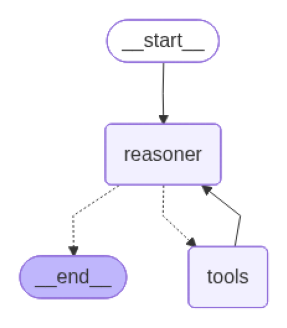

In [ ]:
from PIL import Image
import io
import matplotlib.pyplot as plt

# Generate a Mermaid visualization of the compiled graph
g = app.get_graph()
png_bytes = g.draw_mermaid_png()

img = Image.open(io.BytesIO(png_bytes))
plt.figure(figsize=(12, 4))
plt.imshow(img)
plt.axis("off")
plt.show()


### Command-Line Interface

The project includes an interactive **command-line interface (CLI)** that allows users to communicate with the travel assistant directly from the terminal.

The CLI maintains the conversation history across multiple turns and sends each user message to the compiled LangGraph workflow.

The interface supports:

* Reading user input continuously in an interactive loop
* Invoking the LangGraph agent for each message
* Displaying the tools used during the interaction
* Printing the assistant's final response
* Preserving conversation context between turns
* Exiting the application with an `exit` command
* Resetting the conversation history with a `clear` command

The CLI provides a lightweight way to test the complete agent workflow, including reasoning, dynamic tool selection, tool execution, and multi-turn conversation handling.


In [ ]:
def extract_tool_names_from_new_messages(new_messages):
    """Extract unique tool names from newly generated messages.

    Args:
        new_messages: Messages generated during the current agent turn.

    Returns:
        A list of unique tool names in their original execution order.
    """
    tool_names = []

    for m in new_messages:
        tc = getattr(
            m,
            "tool_calls",
            None,
        )

        if tc:
            for call in tc:
                if isinstance(call, dict):
                    name = call.get("name")
                else:
                    name = getattr(
                        call,
                        "name",
                        None,
                    )

                if name:
                    tool_names.append(
                        str(name)
                    )

        ak = (
            getattr(
                m,
                "additional_kwargs",
                None,
            )
            or {}
        )

        if (
            isinstance(ak, dict)
            and "tool_calls" in ak
        ):
            for call in ak["tool_calls"]:
                fn = (
                    call.get("function", {})
                    if isinstance(call, dict)
                    else {}
                )

                name = fn.get("name")

                if name:
                    tool_names.append(
                        str(name)
                    )

    seen = set()
    out = []

    for n in tool_names:
        if n not in seen:
            seen.add(n)
            out.append(n)

    return out


In [ ]:
def split_new_messages(
    old_msgs,
    new_msgs,
):
    """Identify messages generated during the current turn.

    If the graph returns the complete conversation history,
    previously existing messages are removed. If only new messages
    are returned, the input is preserved as-is.

    Args:
        old_msgs: Messages that existed before the current turn.
        new_msgs: Messages returned by the LangGraph application.

    Returns:
        Messages associated with the current turn.
    """
    if (
        len(new_msgs) >= len(old_msgs)
        and old_msgs
    ):
        return new_msgs[
            len(old_msgs):
        ]

    if not old_msgs:
        return new_msgs

    return new_msgs


In [ ]:
def chat_cli(app):
    """Run an interactive command-line interface for TravelBot.

    The interface maintains conversation history, invokes the
    LangGraph agent, displays tools used during each turn, and
    supports commands for clearing or exiting the conversation.

    Args:
        app: Compiled LangGraph travel-agent application.
    """
    print(
        "TravelBot CLI started."
    )
    print(
        "Commands: exit | clear"
    )
    print(
        "-" * 60
    )

    state = {
        "messages": []
    }

    while True:
        try:
            user_input = input(
                "\nYou: "
            ).strip()

        except (
            EOFError,
            KeyboardInterrupt,
        ):
            print(
                "\nGoodbye."
            )
            break

        if not user_input:
            continue

        cmd = user_input.lower()

        if cmd in {
            "exit",
            "quit",
        }:
            print(
                "Goodbye."
            )
            break

        if cmd == "clear":
            # Reset conversation history
            state = {
                "messages": []
            }

            os.system(
                "cls"
                if os.name == "nt"
                else "clear"
            )

            print(
                "TravelBot CLI started."
            )
            print(
                "Commands: exit | clear"
            )
            print(
                "-" * 60
            )

            continue

        old_messages = list(
            state.get(
                "messages",
                [],
            )
        )

        state["messages"] = (
            old_messages
            + [
                HumanMessage(
                    content=user_input
                )
            ]
        )

        try:
            result = app.invoke(
                state
            )

        except Exception as e:
            print(
                "\n[ERROR] Graph invocation failed: "
                f"{type(e).__name__}: {str(e)}"
            )
            continue

        returned_messages = result.get(
            "messages",
            [],
        )

        state["messages"] = (
            returned_messages
            if returned_messages
            else state["messages"]
        )

        new_messages = split_new_messages(
            old_messages,
            state["messages"],
        )

        tool_names = (
            extract_tool_names_from_new_messages(
                new_messages
            )
        )

        print(
            "\nTools used:",
            (
                ", ".join(tool_names)
                if tool_names
                else "none"
            ),
        )

        final_msg = (
            state["messages"][-1]
            if state["messages"]
            else None
        )

        final_text = (
            getattr(
                final_msg,
                "content",
                "",
            )
            if final_msg
            else ""
        )

        print(
            "\nAssistant:",
            final_text,
        )

In [ ]:
chat_cli(app)

TravelBot CLI started.
Commands: exit | clear
------------------------------------------------------------

You: I want a flight from Tehran to Dubai for next  Tuesday

Tools used: search_flights_amadeus

Assistant: Here are the flight options from Tehran to Dubai for next Tuesday, February 17, 2026:

1. **Flight Number:** X11325
   - **Airline:** X1
   - **Departure:** 18:05
   - **Arrival:** 19:05 (next day)
   - **Duration:** 24h 30m (1 stop)
   - **Price:** €174.41

2. **Flight Number:** EK978
   - **Airline:** Emirates (EK)
   - **Departure:** 04:35
   - **Arrival:** 07:10
   - **Duration:** 2h 5m (non-stop)
   - **Price:** €186.37

3. **Flight Number:** EK980
   - **Airline:** Emirates (EK)
   - **Departure:** 18:40
   - **Arrival:** 21:20
   - **Duration:** 2h 10m (non-stop)
   - **Price:** €186.37

Let me know if you need more information or assistance with booking!

You: I want a hotel in Dubai for the dates February 20th to February 25th.

Tools used: search_hotels_amadeus

A

## Agent Testing Across Multiple Scenarios

The completed travel assistant is evaluated across multiple scenarios to verify tool selection, response quality, and end-to-end workflow behavior.

Each of the seven available tools is tested with at least two different user queries, resulting in a minimum of fourteen test scenarios.

The evaluated tools include:

* Flight Search
* Hotel Search
* Restaurant Search
* Weather Information
* Currency Information
* FAQ Search
* Trip Planning

For each test scenario, the evaluation records:

* User query
* Tool or tools selected by the agent
* Final assistant response
* Brief qualitative assessment of the result

The goal of these tests is to verify that the agent:

* Selects the appropriate tool for each request
* Passes relevant user information correctly to the selected tool
* Handles dates and structured inputs consistently
* Produces readable and useful final responses
* Handles unavailable or incomplete results gracefully
* Maintains the expected behavior across different travel-related requests

The scenarios also help validate the interaction between the LangGraph Reasoner Node and Tools Node under different user intents.


In [ ]:
def extract_tool_names(messages):
    """Extract unique tool names used during an agent run.

    Args:
        messages: LangChain messages returned by the LangGraph workflow.

    Returns:
        A list of unique tool names in their original execution order.
    """
    names = []

    for m in messages:
        tc = getattr(m, "tool_calls", None)
        if tc:
            for call in tc:
                if isinstance(call, dict):
                    n = call.get("name")
                    if n:
                        names.append(str(n))
                else:
                    n = getattr(call, "name", None)
                    if n:
                        names.append(str(n))

        ak = getattr(m, "additional_kwargs", None) or {}
        if isinstance(ak, dict) and "tool_calls" in ak:
            for call in ak["tool_calls"]:
                if isinstance(call, dict):
                    fn = call.get("function", {}) or {}
                    n = fn.get("name")
                    if n:
                        names.append(str(n))

    seen = set()
    out = []
    for n in names:
        if n in seen:
            continue
        seen.add(n)
        out.append(n)
    return out


In [ ]:
def get_final_text(messages):
    """Extract the final assistant response from a message sequence.

    Args:
        messages: Messages returned by the LangGraph workflow.

    Returns:
        The content of the final message, or an empty string
        when no messages are available.
    """
    
    if not messages:
        return ""
    last = messages[-1]
    return getattr(last, "content", "") or ""

In [ ]:
def contains_any(text: str, patterns):
    """Check whether text contains any of the provided patterns.

    Args:
        text: Text to inspect.
        patterns: Collection of case-insensitive substrings.

    Returns:
        True if at least one pattern is present.
    """
    t = text.lower()
    return any(p.lower() in t for p in patterns)

In [ ]:
def regex_any(text: str, patterns):
    """Check whether text matches any regular-expression pattern.

    Args:
        text: Text to inspect.
        patterns: Collection of regular-expression patterns.

    Returns:
        True if at least one pattern matches.
    """
    
    for p in patterns:
        if re.search(p, text, flags=re.I):
            return True
    return False

In [ ]:
@dataclass
class Scenario:
    """Represent a single end-to-end agent test scenario.

    Attributes:
        id: Unique scenario identifier.
        tool_expected: Tool expected to be selected by the agent.
        user_query: User request submitted to the agent.
        extra_notes: Optional notes associated with the scenario.
        quality_check: Optional function used to evaluate the response.
    """
    id: str
    tool_expected: str
    user_query: str
    extra_notes: str = ""
    quality_check: Optional[Callable[[str], Tuple[bool, str]]] = None

In [ ]:
def default_quality_check(tool_name):
    """Create a lightweight response-quality check for a tool.

    Args:
        tool_name: Name of the tool being evaluated.

    Returns:
        A function that evaluates the final assistant response.
    """
    def check(text):
        """Evaluate whether a response contains expected information."""
        t = text.strip()
        if not t:
            return False, "Empty final answer."

        if tool_name == "search_flights_amadeus":
            ok = contains_any(t, ["flight", "airline", "departure", "arrival"]) or regex_any(t, [r"\b\d{1,2}:\d{2}\b"])
            return ok, "Expected flight-like details (airline/times/flight mentions)."

        if tool_name == "search_hotels_amadeus":
            ok = contains_any(t, ["hotel", "check-in", "check out", "night", "price", "rating", "neighborhood"])
            return ok, "Expected hotel-like details (hotel names/prices/areas)."

        if tool_name == "search_restaurants_by_destination":
            ok = contains_any(t, ["restaurant", "cuisine", "cafe", "brunch", "local"]) or regex_any(t, [r"https?://"])
            return ok, "Expected restaurant-like details (cuisine + suggestions + links)."

        if tool_name == "get_weather_info_tavily":
            ok = contains_any(t, ["weather", "forecast", "temperature", "°", "rain", "humidity"])
            return ok, "Expected weather-like details (temp/condition/humidity/rain)."

        if tool_name == "get_currency_info_tavily":
            ok = regex_any(t, [r"\b1\s*[A-Z]{3}\s*=\s*[\d\.]+\s*[A-Z]{3}\b"]) or contains_any(t, ["exchange rate", "convert"])
            return ok, "Expected exchange-rate-like details (1 XXX = YYY ZZZ)."

        if tool_name == "faq_search":
            ok = contains_any(t, ["based on our faq", "q:", "a:"])
            return ok, "Expected FAQ formatted output (Based on our FAQ / Q: / A:)."

        if tool_name == "trip_planning":
            ok = contains_any(t, ["day 1", "itinerary", "morning", "afternoon", "evening"]) or contains_any(t, ["daily", "plan"])
            return ok, "Expected itinerary structure (days or morning/afternoon/evening)."

        return True, "No specific checks."
    return check

In [ ]:
SCENARIOS = [
    Scenario(
        id="T01",
        tool_expected="search_flights_amadeus",
        user_query=(
            "I want to go to Dubai from Tehran next Sunday."
        ),
        quality_check=default_quality_check(
            "search_flights_amadeus"
        ),
    ),
    Scenario(
        id="T02",
        tool_expected="search_flights_amadeus",
        user_query=(
            "Find flights from Tehran to Paris in 30 days "
            "for 2 adults."
        ),
        quality_check=default_quality_check(
            "search_flights_amadeus"
        ),
    ),

    Scenario(
        id="T03",
        tool_expected="search_hotels_amadeus",
        user_query=(
            "I want a hotel in Paris from in 40 days "
            "to in 45 days for 2 adults, "
            "max 2000 AED per night."
        ),
        quality_check=default_quality_check(
            "search_hotels_amadeus"
        ),
    ),
    Scenario(
        id="T04",
        tool_expected="search_hotels_amadeus",
        user_query=(
            "Suggest a hotel in Dubai from in 50 days "
            "to in 54 days, with a maximum budget "
            "of 3000 USD per night."
        ),
        quality_check=default_quality_check(
            "search_hotels_amadeus"
        ),
    ),

    Scenario(
        id="T05",
        tool_expected="search_restaurants_by_destination",
        user_query="Best restaurants in Dubai?",
        quality_check=default_quality_check(
            "search_restaurants_by_destination"
        ),
    ),
    Scenario(
        id="T06",
        tool_expected="search_restaurants_by_destination",
        user_query="Recommend local food places in Rome.",
        quality_check=default_quality_check(
            "search_restaurants_by_destination"
        ),
    ),

    Scenario(
        id="T07",
        tool_expected="get_weather_info_tavily",
        user_query="Weather in Tehran next Sunday.",
        quality_check=default_quality_check(
            "get_weather_info_tavily"
        ),
    ),
    Scenario(
        id="T08",
        tool_expected="get_weather_info_tavily",
        user_query="What will the weather be like in Dubai in 20 days?",
        quality_check=default_quality_check(
            "get_weather_info_tavily"
        ),
    ),

    Scenario(
        id="T09",
        tool_expected="get_currency_info_tavily",
        user_query=(
            "United States Dollars to UAE Dirhams exchange rate."
        ),
        quality_check=default_quality_check(
            "get_currency_info_tavily"
        ),
    ),
    Scenario(
        id="T10",
        tool_expected="get_currency_info_tavily",
        user_query=(
            "I am traveling from Emirates to France. "
            "What is the AED to EUR exchange rate today?"
        ),
        quality_check=default_quality_check(
            "get_currency_info_tavily"
        ),
    ),

    Scenario(
        id="T11",
        tool_expected="faq_search",
        user_query="How do I get a visa?",
        quality_check=default_quality_check(
            "faq_search"
        ),
    ),
    Scenario(
        id="T12",
        tool_expected="faq_search",
        user_query=(
            "What documents do I need for international travel?"
        ),
        quality_check=default_quality_check(
            "faq_search"
        ),
    ),

    Scenario(
        id="T13",
        tool_expected="trip_planning",
        user_query=(
            "Create a 4-day itinerary for Paris "
            "with a focus on food and culture, "
            "from in 60 days to in 64 days."
        ),
        quality_check=default_quality_check(
            "trip_planning"
        ),
    ),
    Scenario(
        id="T14",
        tool_expected="trip_planning",
        user_query=(
            "Plan my trip to Rome from in 70 days "
            "to in 74 days."
        ),
        quality_check=default_quality_check(
            "trip_planning"
        ),
    ),
]

In [ ]:
def run_scenario(
    app,
    scenario: Scenario,
):
    """Execute and evaluate a single agent scenario.

    Args:
        app: Compiled LangGraph application.
        scenario: Scenario to execute.

    Returns:
        A structured report containing tool-selection and
        response-quality evaluation results.
    """
    state = {
        "messages": [
            HumanMessage(
                content=scenario.user_query
            )
        ]
    }

    try:
        result = app.invoke(
            state
        )

        msgs = result.get(
            "messages",
            [],
        )

        used_tools = extract_tool_names(
            msgs
        )

        final_text = get_final_text(
            msgs
        )

        tool_ok = (
            scenario.tool_expected
            in used_tools
        )

        if scenario.quality_check is None:
            qc_ok = True
            qc_note = "No quality check."

        else:
            qc_ok, qc_note = (
                scenario.quality_check(
                    final_text
                )
            )

        return {
            "id": scenario.id,
            "query": scenario.user_query,
            "expected_tool": scenario.tool_expected,
            "used_tools": used_tools,
            "final_output": final_text,
            "tool_ok": tool_ok,
            "quality_ok": qc_ok,
            "quality_note": qc_note,
            "error": None,
        }

    except Exception as e:
        return {
            "id": scenario.id,
            "query": scenario.user_query,
            "expected_tool": scenario.tool_expected,
            "used_tools": [],
            "final_output": "",
            "tool_ok": False,
            "quality_ok": False,
            "quality_note": "Scenario execution failed.",
            "error": (
                f"{type(e).__name__}: {str(e)}"
            ),
        }


def run_all_tests(
    app,
    scenarios,
):
    """Run all agent scenarios and print an evaluation report.

    Args:
        app: Compiled LangGraph application.
        scenarios: Collection of scenarios to evaluate.

    Returns:
        A list containing the report for each scenario.
    """
    reports = []
    passed = 0

    for scenario in scenarios:
        rep = run_scenario(
            app,
            scenario,
        )

        reports.append(rep)

        scenario_passed = (
            rep["tool_ok"]
            and rep["quality_ok"]
            and rep["error"] is None
        )

        if scenario_passed:
            passed += 1

        print(
            "\n" + "=" * 80
        )

        print(
            f"Scenario {rep['id']}"
        )

        print(
            "- User Query:"
        )
        print(
            rep["query"]
        )

        print(
            "- Expected Tool:"
        )
        print(
            rep["expected_tool"]
        )

        print(
            "- Tools Used:"
        )
        print(
            ", ".join(
                rep["used_tools"]
            )
            if rep["used_tools"]
            else "none"
        )

        print(
            "- Final Output:"
        )
        print(
            rep["final_output"]
            or "No final output."
        )

        print(
            "- Quality Analysis:"
        )

        print(
            f"Expected tool used: "
            f"{rep['tool_ok']}"
        )

        print(
            f"Answer quality check: "
            f"{rep['quality_ok']} "
            f"({rep['quality_note']})"
        )

        if rep["error"]:
            print(
                f"- Error: {rep['error']}"
            )

        print(
            "- Overall Result:",
            "PASS"
            if scenario_passed
            else "FAIL",
        )

    print(
        "\n" + "=" * 80
    )

    print(
        f"Test Summary: "
        f"{passed}/{len(scenarios)} scenarios passed."
    )

    return reports

In [184]:
def run_all_tests(app, scenarios):
    reports = []
    passed = 0

    for s in scenarios:
        rep = run_scenario(app, s)
        reports.append(rep)

        print("\n" + "=" * 80)
        print(f"Scenario {rep['id']}")
        print("- User Query:")
        print(rep["query"])
        print("- Tools Used:")
        print(", ".join(rep["used_tools"]) if rep["used_tools"] else "none")
        print("- Final Output:")
        print(rep["final_output"])
        print("- Quality Analysis:")
        print(f"Expected tool used: {rep['tool_ok']}")
        print(f"Answer quality check: {rep['quality_ok']} ({rep['quality_note']})")

    print("\n" + "=" * 80)
    return reports


In [185]:
reports = run_all_tests(app, SCENARIOS)



Scenario T01
- User Query:
I want to go to Dubai from Tehran next Sunday.
- Tools Used:
search_flights_amadeus
- Final Output:
Here are some flight options from Tehran to Dubai for next Sunday, February 22, 2026:

1. **Flight KU516**
   - **Airline:** Kuwait Airways (KU)
   - **Departure:** 13:15
   - **Arrival:** 21:55
   - **Duration:** 8 hours 10 minutes
   - **Stops:** 1
   - **Price:** €171.42

2. **Flight X11364**
   - **Airline:** Unknown (X1)
   - **Departure:** 12:25
   - **Arrival:** 19:05
   - **Duration:** 6 hours 10 minutes
   - **Stops:** 1
   - **Price:** €174.41

3. **Flight X11364**
   - **Airline:** Unknown (X1)
   - **Departure:** 12:25
   - **Arrival:** 10:05 (next day)
   - **Duration:** 21 hours 10 minutes
   - **Stops:** 1
   - **Price:** €174.41

Please let me know if you need more information or assistance with booking!
- Quality Analysis:
Expected tool used: True
Answer quality check: True (Expected flight-like details (airline/times/flight mentions).)

Scena

Batches:   0%|          | 0/1 [00:00<?, ?it/s]


Scenario T11
- User Query:
How do I get a visa?
- Tools Used:
faq_search
- Final Output:
To get a visa, follow these steps:

1. **Check Requirements**: Visa requirements depend on your destination and nationality. Research the specific requirements for the country you plan to visit.

2. **Application Process**: Apply through the embassy or consulate of your destination country. Some countries may offer e-visas or visa-on-arrival options.

3. **Timing**: Start the visa application process 2-3 months before your planned travel date to ensure you have enough time for processing.

Make sure to gather all necessary documents, such as a valid passport, travel insurance, and any required vaccination certificates.
- Quality Analysis:
Expected tool used: True
Answer quality check: False (Expected FAQ formatted output (Based on our FAQ / Q: / A:).)


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


Scenario T12
- User Query:
What documents do I need for international travel?
- Tools Used:
faq_search
- Final Output:
For international travel, you typically need the following documents:

1. **A valid passport**: Ensure it is valid for at least 6 months beyond your planned return date.
2. **Visa**: Check if a visa is required for your destination.
3. **Travel insurance**: It's advisable to have coverage for health and travel-related issues.
4. **Vaccination certificates**: Required for certain destinations, especially for diseases like yellow fever.
5. **Return ticket**: Proof of your return or onward travel may be necessary.

Make sure to check the specific requirements for your destination, as they can vary.
- Quality Analysis:
Expected tool used: True
Answer quality check: False (Expected FAQ formatted output (Based on our FAQ / Q: / A:).)


...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]


Scenario T14
- User Query:
Plan my trip to Rome from Feb 20 to Feb 24.
- Tools Used:
trip_planning
- Final Output:
Here's your trip plan for Rome from February 20 to February 24, 2026:

### Trip Overview
- **Destination:** Rome
- **Arrival Date:** February 20, 2026
- **Departure Date:** February 24, 2026
- **Total Days:** 4

### Daily Itinerary

#### Day 1: February 20, 2026
- **Morning:** Explore local markets and enjoy traditional Roman breakfast items.
- **Afternoon:** Visit iconic sites like the Colosseum and Roman Forum.
- **Evening:** Dinner at a local trattoria, trying classic Roman dishes.
- **Notes:** Keep plans flexible and prioritize nearby activities.

#### Day 2: February 21, 2026
- **Morning:** Visit Vatican City, including St. Peter's Basilica and the Vatican Museums.
- **Afternoon:** Stroll through the beautiful gardens or visit Castel Sant'Angelo.
- **Evening:** Enjoy a leisurely dinner in Trastevere, known for its vibrant atmosphere.
- **Notes:** Consider booking tic